In [1]:
%matplotlib inline
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.linalg as linalg
import IPython
import emcee
import os
from multiprocessing.pool import ThreadPool
from matplotlib.ticker import MaxNLocator
from getdist import plots, MCSamples, loadMCSamples, types
from scipy.special import gamma
from scipy.integrate import quad

os.environ["OMP_NUM_THREADS"] = "1"

plt.rcParams.update({
    "text.usetex": True,                # Usa o motor LaTeX para escrever tudo
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 16,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 14,              # Tamanho da legenda
    "xtick.labelsize": 12,              # Tamanho dos números no eixo X
    "ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

np.random.seed(321)

# Carregando os dados

In [2]:
zhzi, hzi, shzi = np.genfromtxt('data/Hz33Clocks.txt', comments='#', usecols=(0,1,2), unpack=True)
zmod, imf, slib, sps, spsooo = np.genfromtxt('data/data_MM20.dat', comments='#', usecols=(0,1,2,3,4), unpack=True)

In [3]:
priorArray = np.array([[50., 100.], [0.0, 3.0], [-3.0, 3.0], [0.1, 2]])
nstepHz = 5000
ndata = len(zhzi)

# Funções de análise

In [30]:
#Function to identify which model will be used
def free_par(theta, freef, flat):
    if freef == True:
        if flat == False:
            h0, wm, wl, f = theta
            return [h0, wm, wl, f]
        elif flat == True:
            h0, wm, f = theta
            return [h0, wm, 1-wm, f]
        else:
            print("Invalid flatness...")
            return None
    elif freef == False:
        if flat == False:
            h0, wm, wl = theta
            return [h0, wm, wl, 1]
        elif flat == True:
            h0, wm = theta
            return [h0, wm, 1-wm, 1]
        else:
            print("Invalid flatness...")
            return None
    else:
        print("Invalid correction parameter...")
        return None

#Calculate chi2 for the model
def chi2Hz(par):
    E2 = par[1]*(1+zhzi)**3+(1-par[1]-par[2])*(1+zhzi)**2+par[2]

    if np.any(E2<0):
        return np.inf

    Hzm = par[0]*np.sqrt(E2)
    dhz = hzi-Hzm
    inv_covCorr = inv_cov/par[3]**2

    return np.dot(np.dot(dhz.T, inv_covCorr), dhz)

#Check if parameters are in prior interval
def lnpriorHz(par):
    for i in range(len(par)):
        if not priorArray[i][0] < par[i] < priorArray[i][1]:
            return -np.inf
    return 0.0

#Calculate the likelihood
def lnlikeHz(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2 - ndata*np.log(par[3])

def lnlikeHzA(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2 - ndata*np.log(par[3])


def lnprobHz(theta, freef, flat):
    par = free_par(theta, freef, flat)
    
    lp = lnpriorHz(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHz(par)

#Minimize chi2
def find_bestfit(lnlike, par_ml, parnames, freef, flat):
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda par_ml, freef, flat: -2*lnlike(par_ml, freef, flat)
    result = op.minimize(chi2, par_ml, args=(freef, flat))
    if not result['success']:
        result = op.minimize(chi2, par_ml, args=(freef, flat), method='Nelder-Mead', options={'maxiter': 10000})
    par_ml = result['x']
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    t2 = time.time()
    print('Total time: {0:5.3f} seg'.format(t2-t1))
    return result

#Run MC
def run_emcee(par_ml, nwalkers, lnprob, freef, flat, ainput, nsteps):
    ndim = len(par_ml)
    pos = [par_ml +1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    with ThreadPool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=[freef, flat], a=ainput, pool=pool)
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    return sampler

#Remove burn in
def tira_burnin(sampler, burnin, ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples


def burninthin(sampler, tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

#MC results
def MC_result(samples, par_ml, parnames):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865525393149998], axis=0)[0]
    par_valp = np.percentile(samples, [84.13447460685], axis=0)[0]
    par_valm2 = np.percentile(samples, [2.275013194800002], axis=0)[0]
    par_valp2 = np.percentile(samples, [97.7249868052], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    par_sigm2 = par_mean - par_valm2
    par_sigp2 = par_valp2 - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} +{3:5.5f} -{4:5.5f} -{5:5.5f} (median: {6:5.5f}, ml: {7:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigp2[i],par_sigm[i],par_sigm2[i],par_median[i],par_ml[i]))

def best_par(samples):
    return np.mean(samples,axis=0)

#Insert a derived paramater
def insertDerived(sample, parnames, parlabel, num, gsample, derived, derivedName, derivedLabel):
    n = np.zeros(num)
    
    if derivedName not in parnames:
        newSample = np.c_[sample, derived]
        parnames.append(derivedName)
        gsample.addDerived(derived, name=derivedName, label=derivedLabel)
        
        return newSample, gsample, parnames, n

    elif derivedName in parnames:
        print('Parâmetro dependente já adicionado.')

        return sample, gsample, parnames, n

#Distribution funcion for chi2
def chiDist(chi, n):
    return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

#Calculate cdf for chiDist
def chiCDF(x, n):
    res = np.zeros_like(x)
    for i, val in enumerate(x):
        y, err = quad(chiDist, 0, val, args=(n))
        res[i]=y
    return res

#Plot chi2 cdf
def plotChiDist(chimin, par, ndata, name):
    n = ndata - par
    chi = np.linspace(0, 2.5, 500)
    chiv = np.full((500), chimin/n)
    hv = chiDist(chi, n)
    cdf = chiCDF(chi, n)
    y = np.linspace(0, 1.8, 500)
    moda = 1 - 2/n
    
    plt.plot(chi, hv, label=r"$h _{\nu}$")
    plt.plot(chi, cdf, label="CDF")
    plt.plot(np.full((500), moda), y, '--', label=r"$(\chi ^{2} _{\nu})_{\mathrm{mp}}$" + "$= {0}$".format(np.round(moda, 3)))
    plt.plot(chiv, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(np.round(chimin/n, 3)))
    
    plt.xticks(np.arange(0.0, 2.51, 0.5))
    plt.yticks(np.arange(0.0, 1.76, 0.25))
    plt.axis((0, 2.5, 0, 1.75))
    plt.grid(linestyle='-.', linewidth='0.5')
    plt.minorticks_on()
    
    plt.ylabel(r'$h_{\nu}$')
    plt.xlabel(r'$\chi _{\nu} ^{2}$')
    plt.legend(loc='best')
   
    if not name == 0:
        plt.savefig('fig/'+name+'.pdf')
    
    plt.show()

def chi2_reduzido(samples, freef, flat, par, name=0):
    chi2mC = chi2Hz(free_par(best_par(samples), freef=freef, flat=flat))
    chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata-len(par)), args=(ndata-len(par)))
    plotChiDist(chi2mC, len(par), ndata, name=name)
    print(f'Probabilidade = {chivCperc*100}%')
    print(f'chi2v = {chi2mC/(ndata-len(par))}')
    print(f'chi2v mais provável = {1 - 2/(ndata-len(par))}')

def MCResult(sampler):
    if hasattr(sampler, 'products'):
        gdsamples = sampler.products()['sample'][0].to_getdist()
    else:
        gdsamples = sampler
    
    stats = gdsamples.getMargeStats()

    resultados = {'params': {}}

    for parametro in stats.names:
        par_stats = stats.parWithName(parametro.name)

        media = par_stats.mean

        # Erros de 1s
        inf_1s = par_stats.limits[0].lower
        sup_1s = par_stats.limits[0].upper

        # Erros de 2s
        inf_2s = par_stats.limits[1].lower
        sup_2s = par_stats.limits[1].upper

        print(f'{parametro.name} = {media:.4f} + {(sup_1s - media):.4f} + {(sup_2s - media):.4f} -{(media - inf_1s):.4f} -{(media - inf_2s):.4f}')

# Matriz de covariância: stat + imf + slib + spsooo

In [5]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
spsooo_intp = np.interp(zhzi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_slib + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

## OLCDM sem correção

In [6]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  63.919914204009274
wm  =  0.3833000763764333
wl  =  0.7587115253684147
chi2min = 13.792909513381943
Total time: 0.017 seg


In [7]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 167.12it/s]

Acceptance fraction: [0.6314 0.6332 0.6078 0.6258 0.622  0.625  0.6214 0.6412 0.6236 0.6222
 0.6178 0.6186 0.6198 0.629  0.6286 0.6296 0.6242 0.6098 0.6204 0.6254
 0.6252 0.625  0.6106 0.6232 0.6362 0.6318 0.6222 0.6186 0.619  0.615
 0.6324 0.6224 0.6336 0.6458 0.6278 0.6218 0.6182 0.616  0.6112 0.635
 0.6174 0.6228 0.6238 0.608  0.6252 0.6372 0.6174 0.6316 0.642  0.6238
 0.6182 0.6194 0.6348 0.6246 0.6206 0.6312 0.6356 0.6182 0.6142 0.6226
 0.6082 0.628  0.6404 0.6274 0.6352 0.6126 0.6238 0.6142 0.6382 0.6316
 0.6364 0.6142 0.6258 0.626  0.6376 0.625  0.6176 0.6172 0.6126 0.6302
 0.6292 0.6374 0.6192 0.6268 0.6252 0.623  0.612  0.6076 0.6248 0.6216
 0.635  0.6204 0.6224 0.6286 0.6246 0.617  0.6324 0.62   0.6344 0.618 ]
Minimum acceptance: 0.6076
Maximum acceptance: 0.6458


In [9]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[41.55547436 39.09684139 39.34069611]
120.3210907227679
Convergiu! :)


In [10]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [11]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 62.43834 +7.16098 +15.32791 -7.43578 -11.50239 (median: 61.93169, ml: 63.91991)
wm = 0.39932 +0.22083 +0.45377 -0.22891 -0.36827 (median: 0.38516, ml: 0.38330)
wl = 0.70899 +0.41837 +0.79859 -0.43291 -0.82908 (median: 0.72415, ml: 0.75871)


In [12]:
gsamplesHzC_cons = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC_cons.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


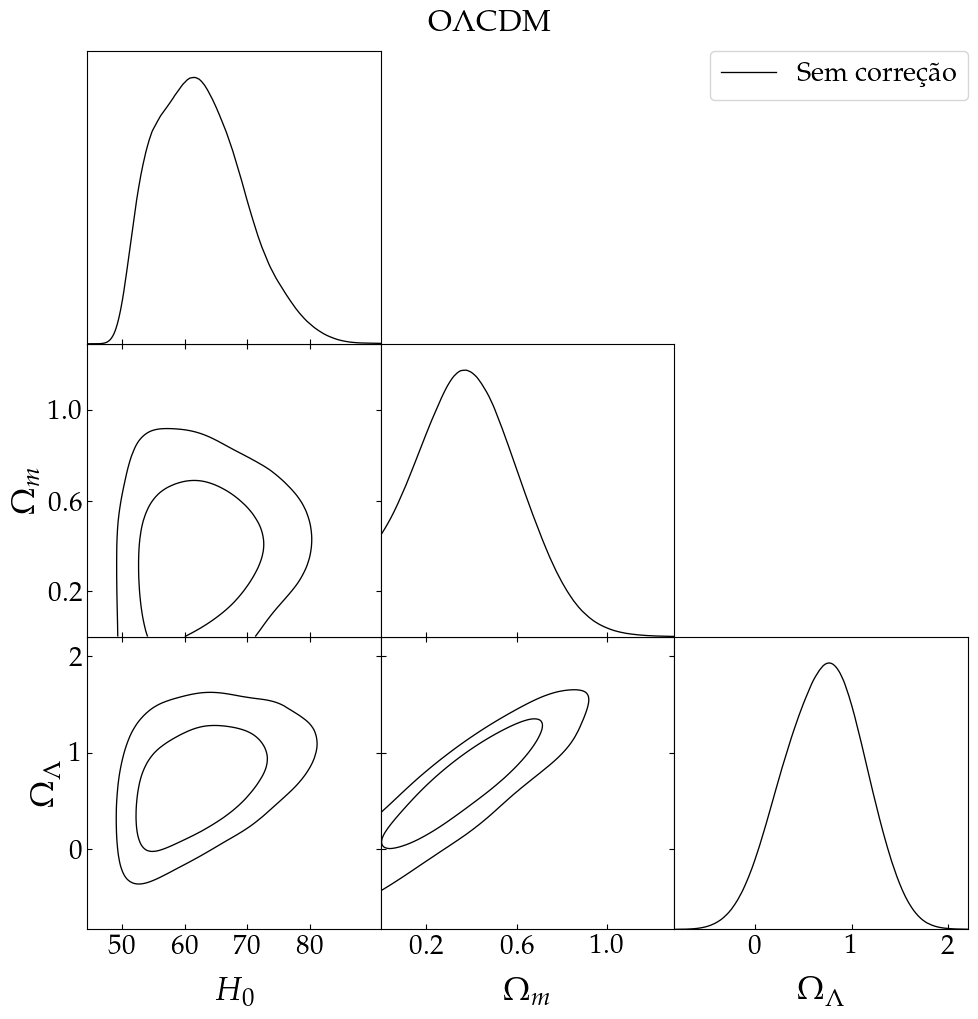

In [13]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_cons], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
g.export('fig/OLCDM-slib_spsooo-no-f.pdf')
plt.show()

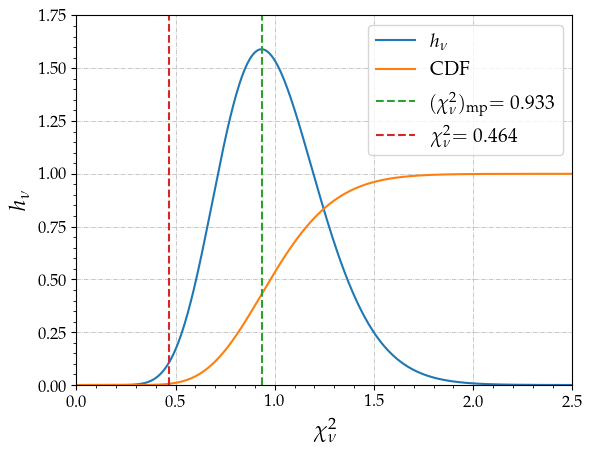

Probabilidade = 0.5478633658998421%
chi2v = 0.4643860572634339
chi2v mais provável = 0.9333333333333333


In [31]:
chi2_reduzido(samplesHzC, False, False, par_HzC)

## OLCDM com correção

In [18]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  63.91998162768951
wm  =  0.3832975482066293
wl  =  0.7587081517271704
f  =  0.6465038026144025
chi2min = 4.21235414469394
Total time: 0.038 seg


In [19]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:32<00:00, 155.47it/s]

Acceptance fraction: [0.584  0.578  0.572  0.5844 0.5772 0.5852 0.5796 0.5952 0.5886 0.5878
 0.574  0.5826 0.5812 0.5854 0.595  0.5906 0.584  0.5774 0.5818 0.5886
 0.5726 0.5798 0.585  0.5832 0.5716 0.5992 0.5852 0.5832 0.5794 0.5892
 0.5782 0.5774 0.585  0.5874 0.5908 0.5808 0.579  0.5842 0.5694 0.5732
 0.5842 0.5808 0.5706 0.5884 0.5858 0.5962 0.5756 0.5888 0.5972 0.5852
 0.59   0.5806 0.579  0.567  0.5748 0.5764 0.5928 0.5616 0.569  0.5862
 0.5638 0.5748 0.5894 0.5922 0.5906 0.5872 0.589  0.5722 0.5708 0.573
 0.586  0.5718 0.5734 0.5824 0.5856 0.5932 0.5806 0.5778 0.5792 0.574
 0.5808 0.5842 0.5874 0.5864 0.5816 0.5894 0.5802 0.5796 0.5768 0.5834
 0.5836 0.5746 0.5888 0.5926 0.5836 0.5798 0.5824 0.5754 0.577  0.5716]
Minimum acceptance: 0.5616
Maximum acceptance: 0.5992


In [20]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[45.33759839 46.02119516 46.57287329 44.9488329 ]
107.3586327576893
Convergiu! :)


In [21]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [22]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 62.37498 +5.61763 +11.61832 -5.79461 -10.58713 (median: 62.21778, ml: 63.91998)
wm = 0.37453 +0.16740 +0.33931 -0.17291 -0.31972 (median: 0.37176, ml: 0.38330)
wl = 0.68319 +0.33154 +0.60667 -0.33783 -0.70001 (median: 0.70055, ml: 0.75871)
f = 0.70597 +0.09371 +0.21403 -0.09167 -0.15786 (median: 0.69536, ml: 0.64650)


In [24]:
gsamplesHzCF_cons = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF_cons.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


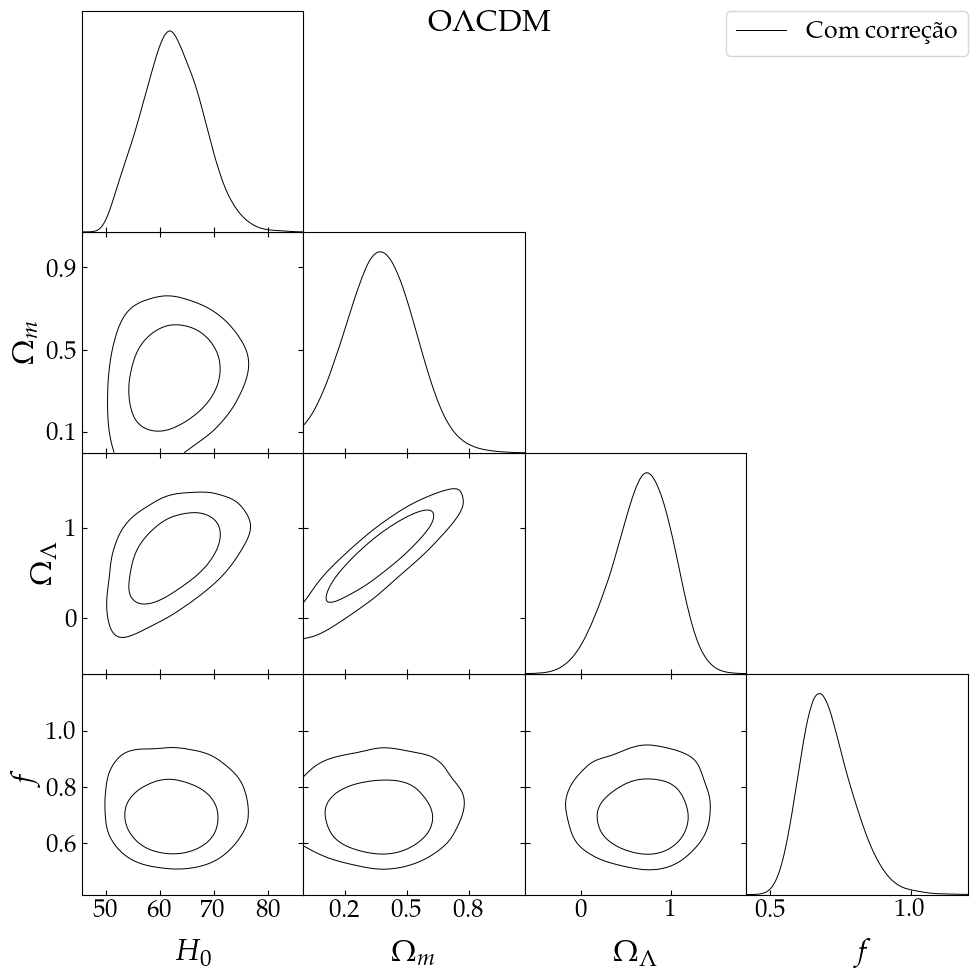

In [26]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF_cons], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-slib_spsooo-f.pdf')
plt.show()

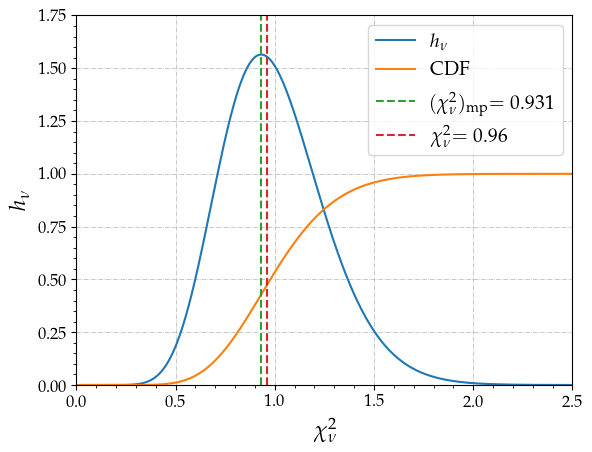

Probabilidade = 47.27651553593958%
chi2v = 0.9595143962356574
chi2v mais provável = 0.9310344827586207


In [32]:
chi2_reduzido(samplesHzCF, True, False, par_HzCF)

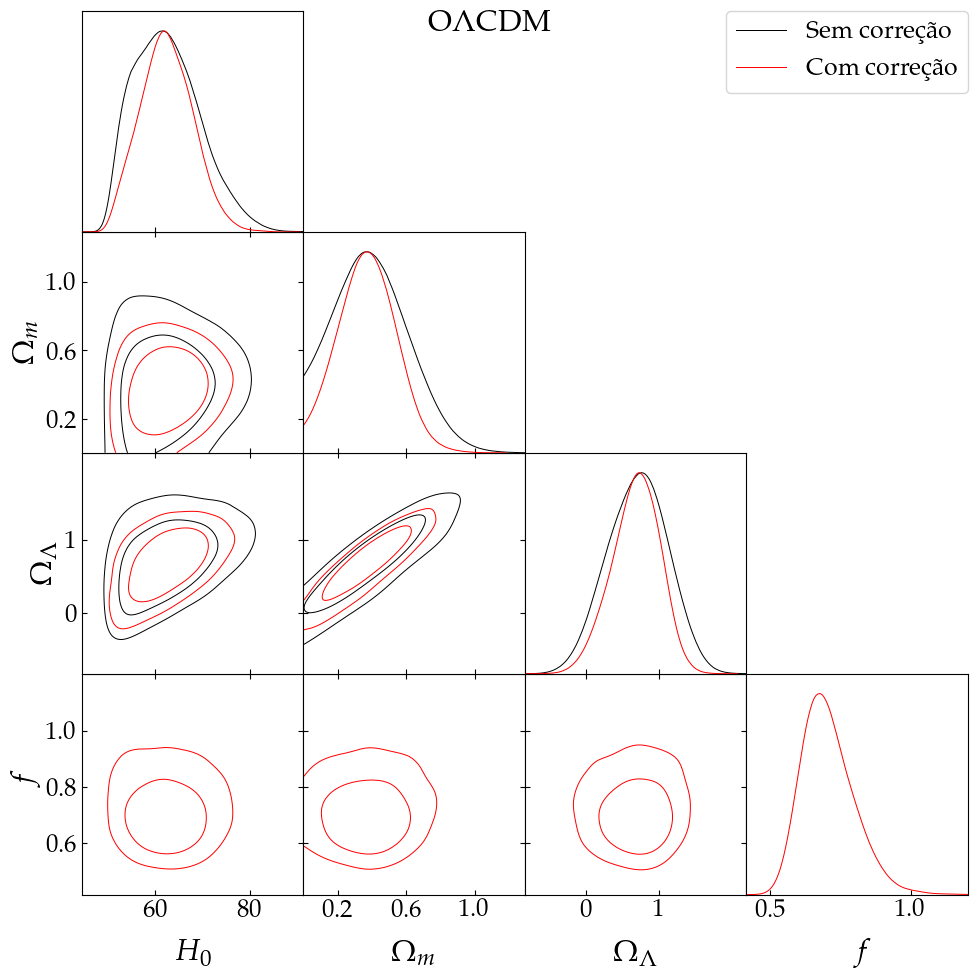

In [33]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_cons, gsamplesHzCF_cons], ['H0', 'wm', 'wl', 'f'], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-slib_spsooo.pdf')
plt.show()

## FLCDM sem correção

In [34]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  63.2190212830185
wm  =  0.33688633703147297
chi2min = 13.83213381297701
Total time: 0.012 seg


In [35]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:31<00:00, 156.74it/s]

Acceptance fraction: [0.7198 0.718  0.7058 0.7086 0.7104 0.7066 0.7064 0.7192 0.7102 0.7188
 0.6998 0.7098 0.7082 0.7146 0.716  0.7208 0.727  0.7008 0.7046 0.7146
 0.709  0.7188 0.7092 0.7176 0.7134 0.714  0.715  0.7184 0.713  0.717
 0.7156 0.7208 0.715  0.7092 0.7092 0.7102 0.7162 0.7148 0.7112 0.706
 0.6896 0.7122 0.7168 0.7178 0.7124 0.7152 0.7046 0.7296 0.732  0.7158
 0.7074 0.7144 0.7078 0.7154 0.706  0.7268 0.7188 0.7028 0.7064 0.7148
 0.7    0.7106 0.7248 0.7152 0.7142 0.721  0.7188 0.6938 0.7076 0.7108
 0.7214 0.7194 0.7056 0.7054 0.7192 0.7144 0.7178 0.6974 0.7104 0.7282
 0.7182 0.717  0.7166 0.714  0.7094 0.7102 0.7022 0.7108 0.7114 0.7104
 0.7084 0.7098 0.7096 0.71   0.7176 0.703  0.7234 0.7102 0.7104 0.706 ]
Minimum acceptance: 0.6896
Maximum acceptance: 0.732


In [36]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[32.87115493 32.35582839]
152.10904548347415
Convergiu! :)


In [37]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(30800, 2)


In [38]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 62.58236 +6.94550 +14.19691 -7.03303 -11.43990 (median: 62.20768, ml: 69.19300)
wm = 0.35435 +0.07604 +0.17310 -0.07559 -0.13022 (median: 0.34653, ml: 0.24809)


In [39]:
gsamplesHzF_cons = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF_cons.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


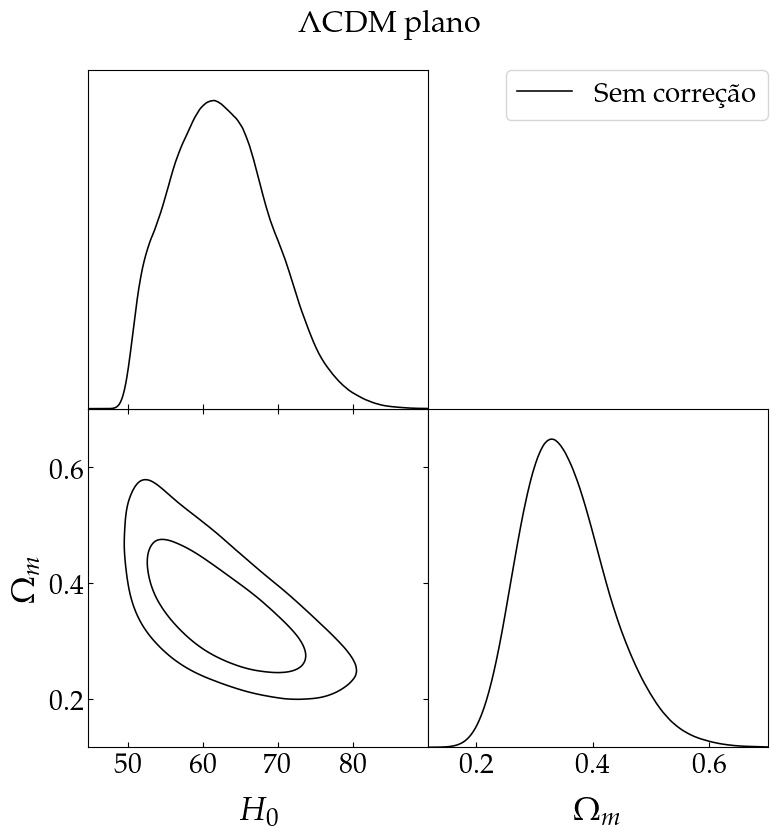

In [40]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_cons], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-slib_spsooo-no_f.pdf')
plt.show()

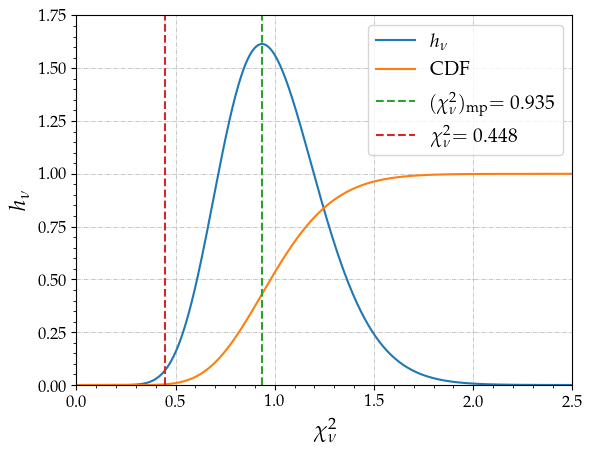

Probabilidade = 0.3490290117326997%
chi2v = 0.4482803879478791
chi2v mais provável = 0.935483870967742


In [41]:
chi2_reduzido(samplesHzF, False, True, par_HzF)

## FLCDM com correção

In [42]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  63.21901725866309
wm  =  0.33688636334204297
f  =  0.6474222383389575
chi2min = 4.306066413905846
Total time: 0.010 seg


In [44]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:33<00:00, 150.50it/s]

Acceptance fraction: [0.6506 0.6536 0.6324 0.6272 0.6412 0.6442 0.6384 0.638  0.642  0.6414
 0.6278 0.6368 0.633  0.6484 0.642  0.6444 0.6472 0.6468 0.647  0.6356
 0.6422 0.6334 0.643  0.638  0.6494 0.6566 0.6528 0.6406 0.6378 0.6534
 0.6418 0.6474 0.633  0.648  0.6482 0.637  0.6386 0.6452 0.6394 0.6438
 0.6328 0.642  0.6548 0.6538 0.6404 0.645  0.6246 0.6572 0.6598 0.6404
 0.6398 0.6382 0.6422 0.6232 0.641  0.6476 0.6412 0.6222 0.6424 0.64
 0.6352 0.642  0.6454 0.6564 0.6454 0.6322 0.6358 0.638  0.6342 0.6492
 0.6456 0.635  0.639  0.6282 0.6456 0.6438 0.6544 0.6382 0.635  0.646
 0.6382 0.6426 0.654  0.6458 0.6476 0.6346 0.6328 0.633  0.6462 0.633
 0.6484 0.6402 0.6476 0.6524 0.6466 0.63   0.654  0.6394 0.6334 0.6316]
Minimum acceptance: 0.6222
Maximum acceptance: 0.6598


In [46]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[38.94636805 37.59195047 35.79356057]
128.3816758903617
Convergiu! :)


In [47]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(28900, 3)


In [48]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 62.69579 +5.13593 +10.22028 -5.18915 -10.06553 (median: 62.66689, ml: 63.21902)
wm = 0.34770 +0.05401 +0.12795 -0.05354 -0.09630 (median: 0.34266, ml: 0.33689)
f = 0.69543 +0.09027 +0.21569 -0.09057 -0.15754 (median: 0.68554, ml: 0.64742)


In [49]:
gsamplesHzFf_cons = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf_cons.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


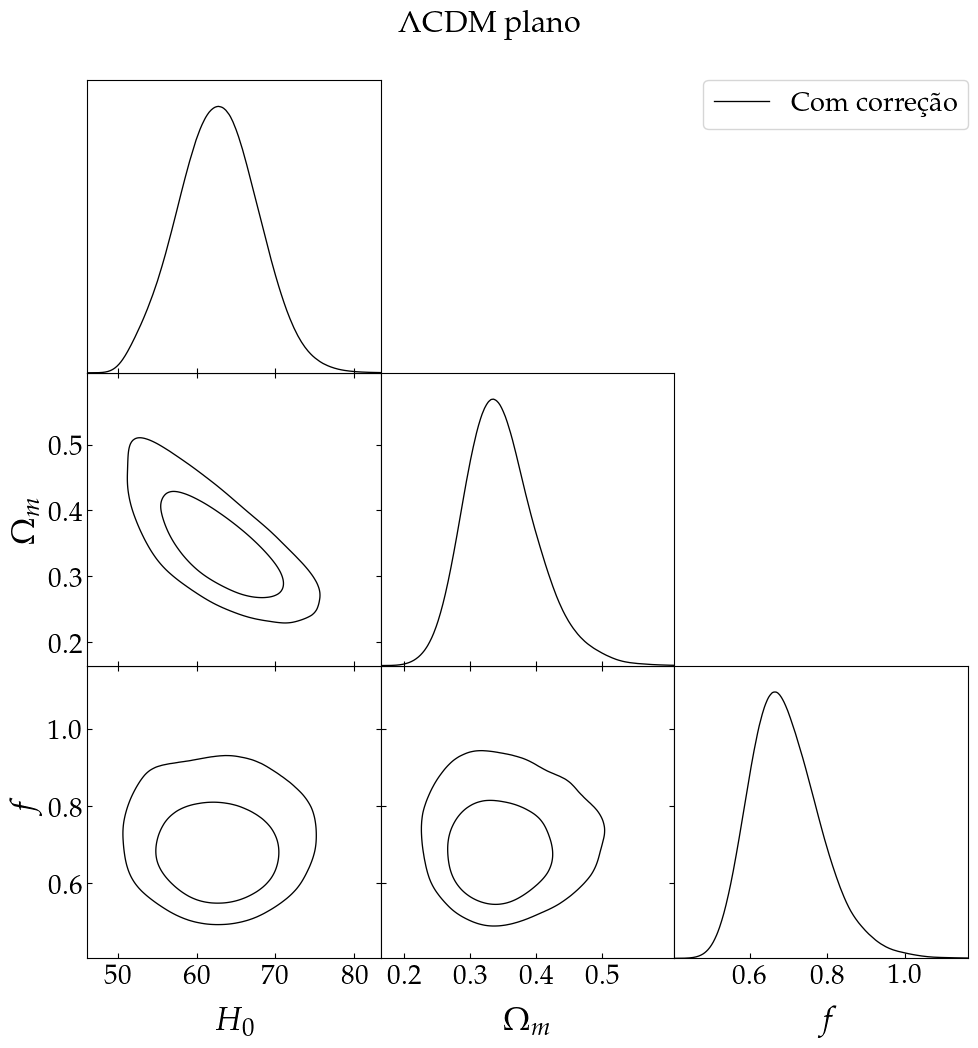

In [50]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf_cons], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-slib_spsooo-f.pdf')
plt.show()

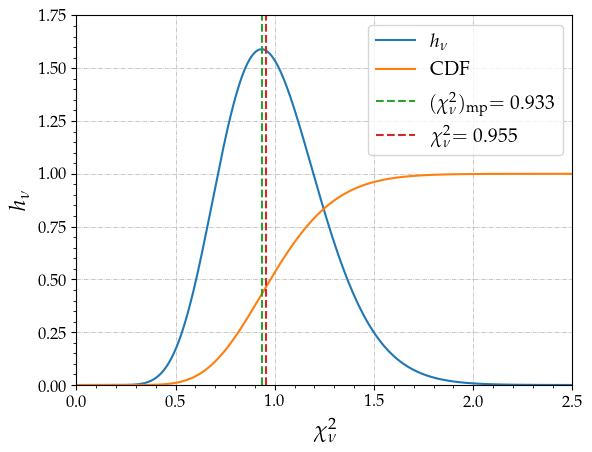

Probabilidade = 46.38085160311704%
chi2v = 0.9548999516827236
chi2v mais provável = 0.9333333333333333


In [51]:
chi2_reduzido(samplesHzFf, True, True, par_HzFf)

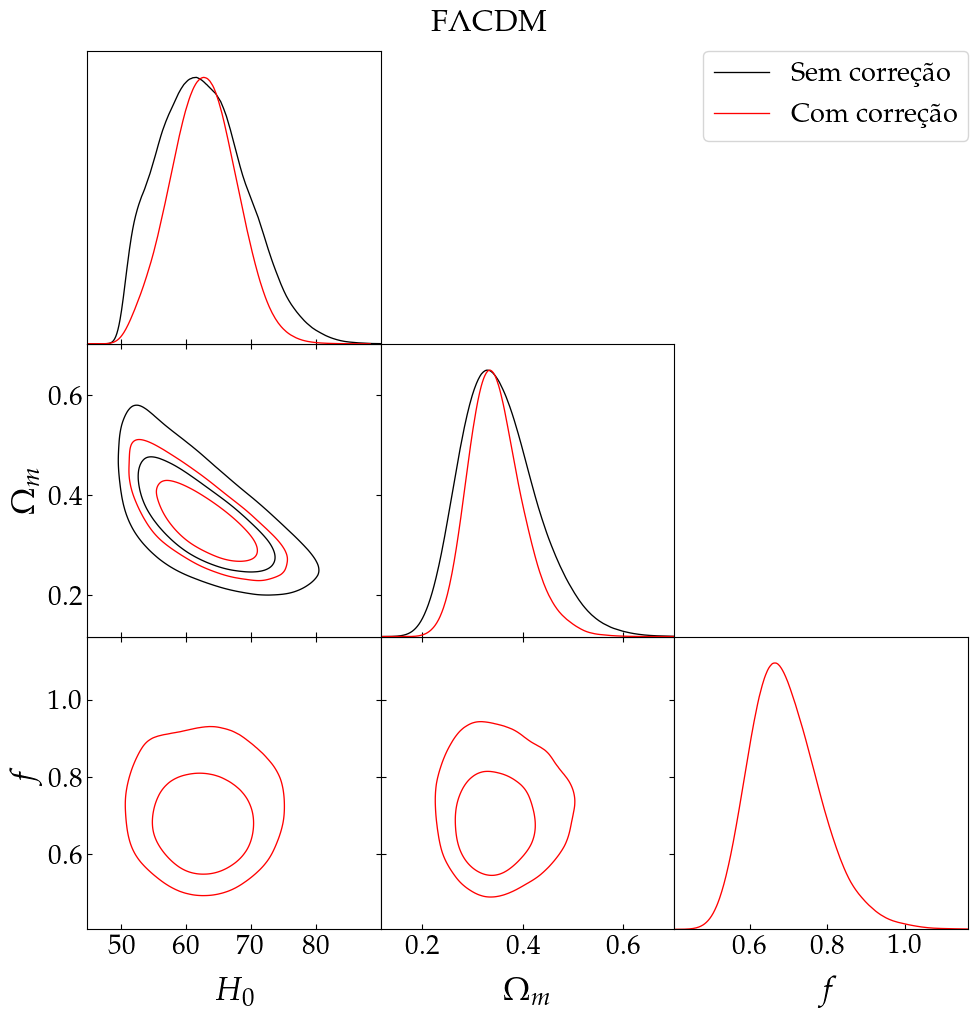

In [53]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_cons, gsamplesHzFf_cons], ['H0', 'wm', 'f'], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22, y=1.02)
g.export('fig/FLCDM-slib_spsooo.pdf')
plt.show()

# Matriz de covariância: stat + imf + slib + sps

In [54]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
sps_intp = np.interp(zhzi, zmod, sps)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_sps = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = hzi[i] * sps_intp[i] * hzi[j] * sps_intp[j]

cov_mat = cov_mat_imf + cov_mat_slib + cov_mat_sps + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

## OLCDM sem correção

In [55]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  59.45320816508737
wm  =  0.4685340170125521
wl  =  0.7848449747021752
chi2min = 13.478981037894476
Total time: 0.014 seg


In [56]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 166.96it/s]

Acceptance fraction: [0.6078 0.617  0.5772 0.6096 0.6004 0.5856 0.5974 0.6158 0.6106 0.6026
 0.5988 0.606  0.5974 0.598  0.607  0.6332 0.6052 0.5926 0.6068 0.6166
 0.5904 0.5974 0.6044 0.6018 0.6066 0.6242 0.605  0.604  0.5974 0.6158
 0.5912 0.5972 0.6146 0.622  0.6162 0.585  0.6138 0.606  0.5946 0.602
 0.5904 0.6066 0.6038 0.6064 0.5964 0.6102 0.603  0.6208 0.6128 0.6068
 0.6022 0.6212 0.6028 0.6082 0.6064 0.613  0.6112 0.596  0.609  0.6064
 0.5828 0.601  0.5998 0.619  0.607  0.6138 0.5988 0.5978 0.5984 0.6072
 0.609  0.6082 0.5996 0.5988 0.6022 0.5938 0.6114 0.5928 0.6054 0.6074
 0.5984 0.6174 0.6168 0.604  0.5928 0.603  0.601  0.602  0.614  0.5876
 0.6132 0.6042 0.618  0.62   0.6144 0.588  0.6108 0.6098 0.6134 0.6126]
Minimum acceptance: 0.5772
Maximum acceptance: 0.6332


In [57]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[48.75836074 41.28503437 42.13335548]
102.54651558735989
Convergiu! :)


In [58]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [59]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 60.19645 +7.65155 +17.78140 -7.50001 -9.81056 (median: 58.71262, ml: 59.45321)
wm = 0.49900 +0.27410 +0.60330 -0.28121 -0.45444 (median: 0.47718, ml: 0.46853)
wl = 0.79789 +0.45044 +0.90308 -0.46454 -0.89160 (median: 0.80548, ml: 0.78484)


In [60]:
gsamplesHzC1 = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


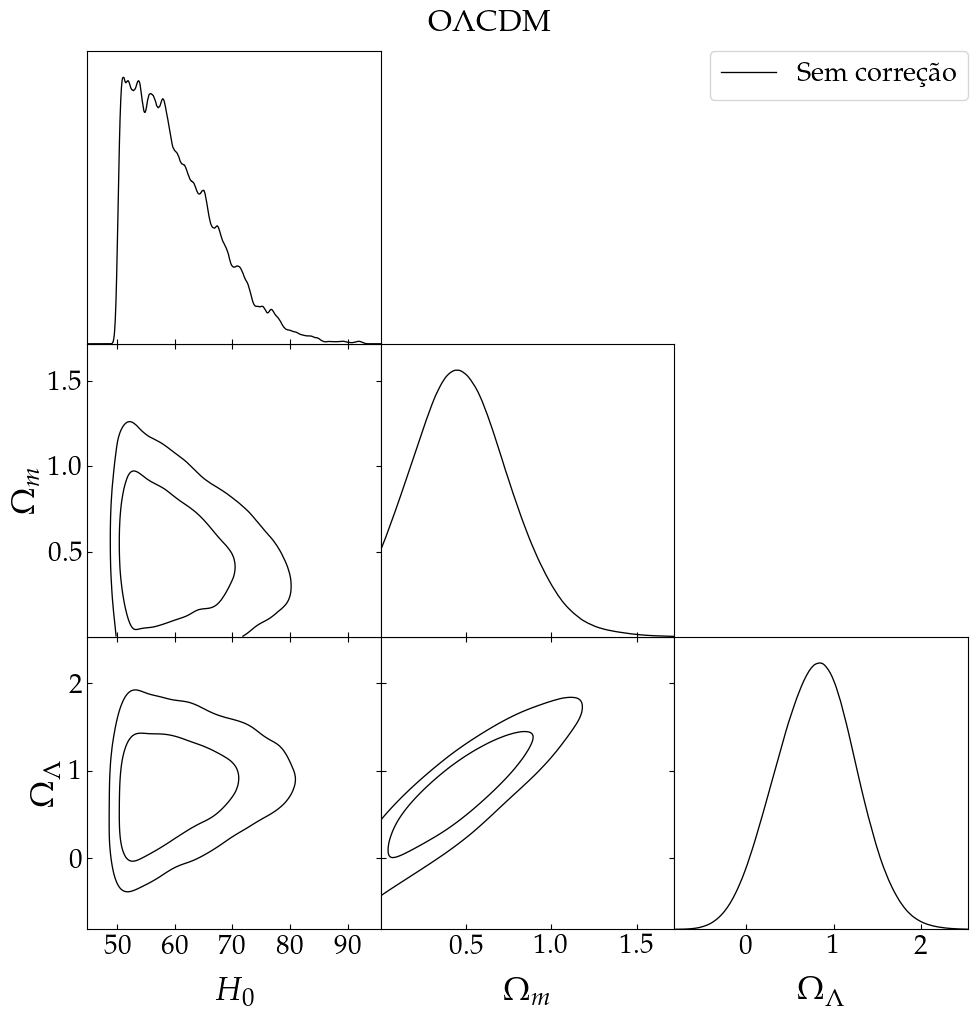

In [62]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC1], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
g.export('fig/OLCDM-slib_sps-no_f.pdf')
plt.show()

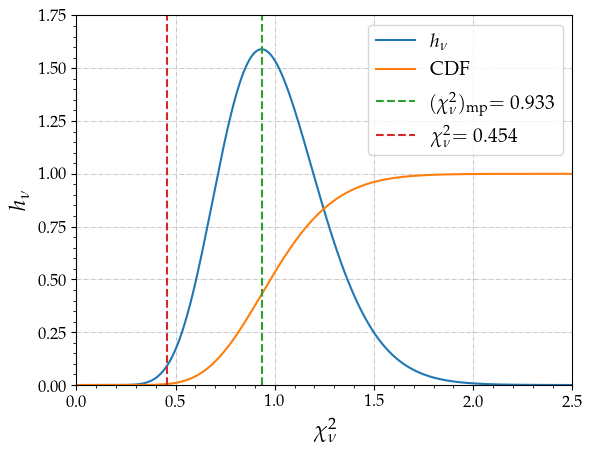

Probabilidade = 0.4506612035594143%
chi2v = 0.45417065857001404
chi2v mais provável = 0.9333333333333333


In [64]:
chi2_reduzido(samplesHzC, False, False, par_HzC)

## OLCDM com correção

In [65]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  59.45322569270124
wm  =  0.4685337561067378
wl  =  0.7848450195369112
f  =  0.6391040418701225
chi2min = 3.452590366485424
Total time: 0.012 seg


/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [66]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 162.05it/s]

Acceptance fraction: [0.5686 0.5604 0.554  0.5654 0.5694 0.5632 0.5598 0.5604 0.5706 0.5776
 0.5602 0.5576 0.5548 0.5626 0.5612 0.5654 0.5674 0.5784 0.5692 0.5676
 0.5588 0.5722 0.5508 0.5742 0.5628 0.5576 0.5572 0.5594 0.5556 0.5802
 0.5624 0.5776 0.565  0.5774 0.5588 0.5612 0.56   0.5594 0.5526 0.556
 0.5594 0.5684 0.5716 0.5486 0.5554 0.5814 0.563  0.5736 0.5784 0.5556
 0.5648 0.5656 0.5584 0.558  0.568  0.5744 0.5818 0.5632 0.5572 0.5668
 0.5552 0.565  0.5692 0.5522 0.5636 0.5706 0.5674 0.5562 0.5714 0.574
 0.561  0.55   0.5546 0.5674 0.5636 0.56   0.5686 0.551  0.568  0.5676
 0.5588 0.5678 0.5782 0.5708 0.5738 0.5574 0.553  0.5592 0.5554 0.5536
 0.568  0.5686 0.5548 0.5758 0.5772 0.5656 0.5796 0.5532 0.5636 0.5678]
Minimum acceptance: 0.5486
Maximum acceptance: 0.5818


In [67]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[54.73447875 48.75825576 49.88695856 47.67890185]
91.35009803299913
Convergiu! :)


In [68]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [69]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 59.05316 +6.12001 +13.76437 -6.20796 -8.60447 (median: 58.25160, ml: 59.45323)
wm = 0.48168 +0.20808 +0.44669 -0.21299 -0.39734 (median: 0.47414, ml: 0.46853)
wl = 0.76137 +0.34362 +0.68216 -0.36131 -0.74321 (median: 0.77926, ml: 0.78485)
f = 0.69225 +0.09015 +0.21021 -0.08997 -0.15550 (median: 0.68238, ml: 0.63910)


In [70]:
gsamplesHzCF1 = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


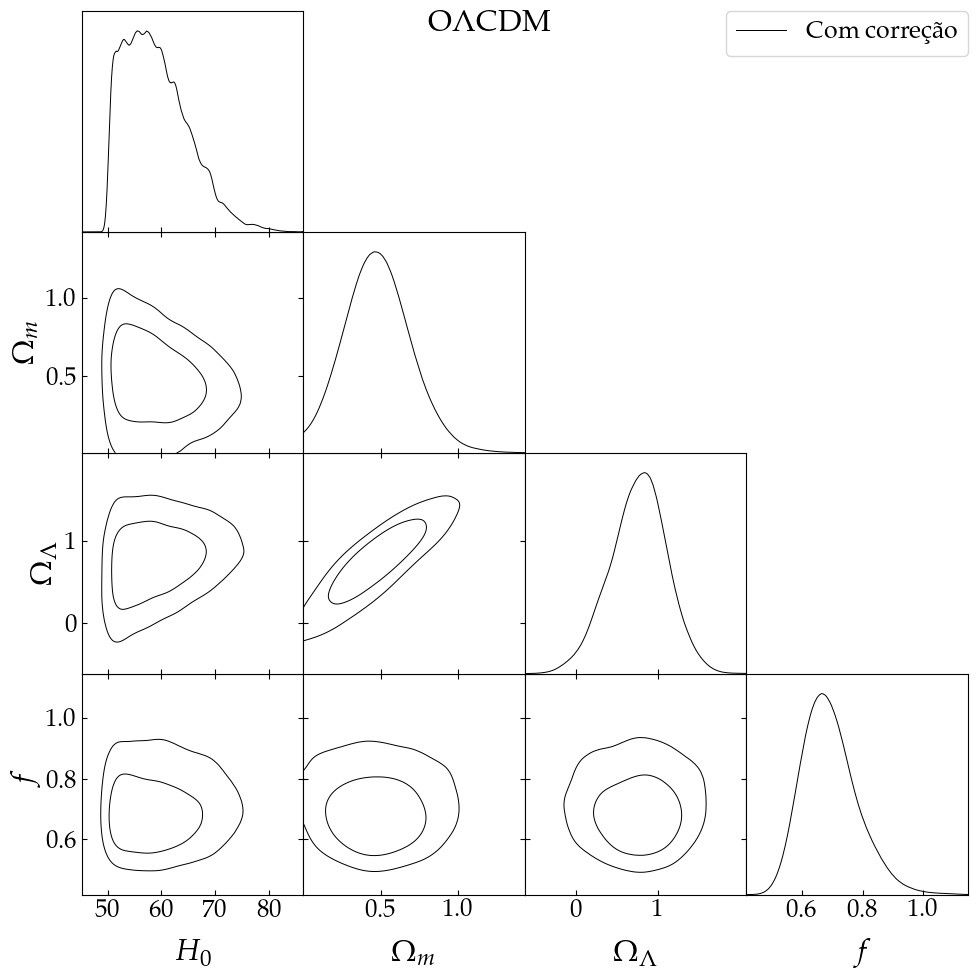

In [71]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF1], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-slib_sps-f.pdf')
plt.show()

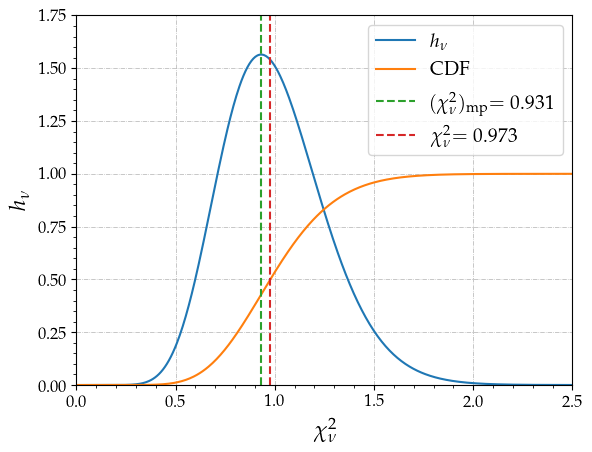

Probabilidade = 49.433310762809086%
chi2v = 0.9734321857212093
chi2v mais provável = 0.9310344827586207


In [72]:
chi2_reduzido(samplesHzCF, True, False, par_HzCF)

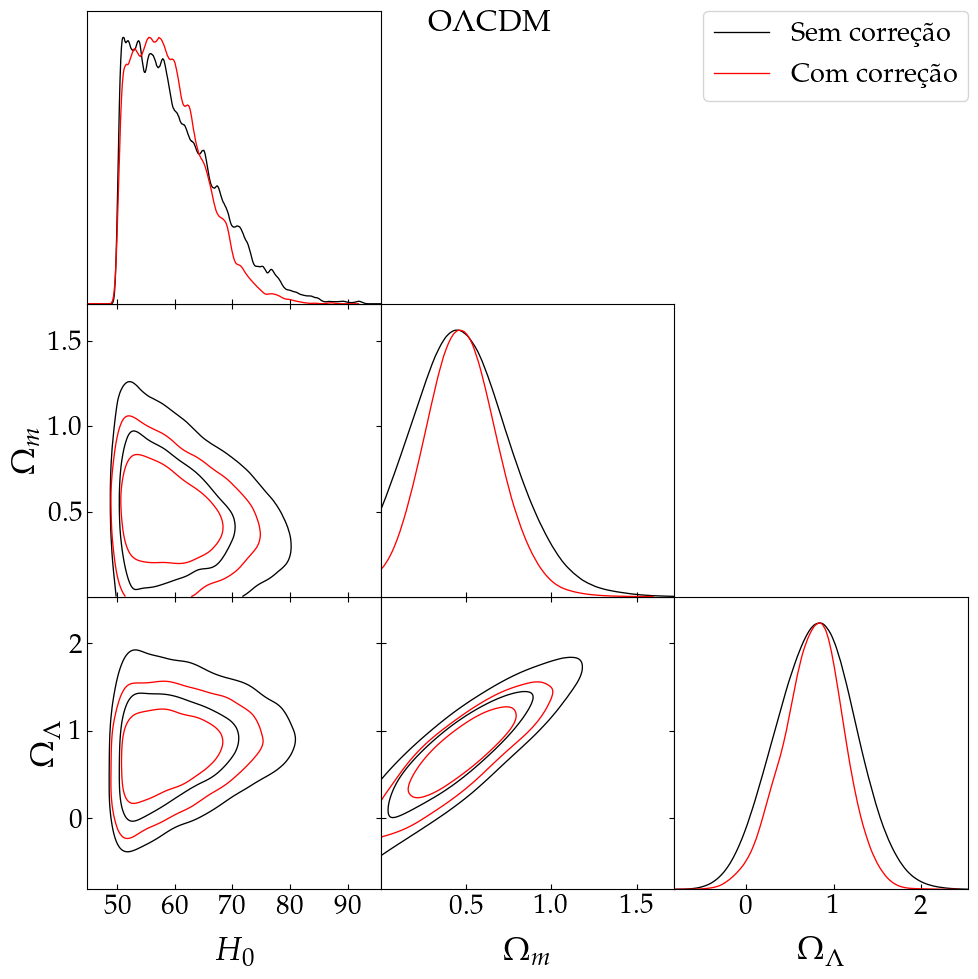

In [73]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC1, gsamplesHzCF1], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-slib_sps.pdf')
plt.show()

## FLCDM sem correção

In [74]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  58.840379173281995
wm  =  0.38085847284234164
chi2min = 13.577361245927824
Total time: 0.007 seg


In [75]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 162.01it/s]

Acceptance fraction: [0.6906 0.6964 0.6758 0.6986 0.6918 0.6952 0.6854 0.7022 0.6824 0.692
 0.684  0.6988 0.6888 0.6914 0.6826 0.6964 0.6944 0.6834 0.6868 0.6892
 0.6918 0.6796 0.6854 0.6972 0.7018 0.6976 0.6882 0.7004 0.6908 0.7058
 0.6948 0.6926 0.6882 0.71   0.696  0.689  0.6912 0.7    0.6876 0.6886
 0.6766 0.6886 0.7002 0.6918 0.6932 0.7058 0.6812 0.6934 0.7034 0.6886
 0.6896 0.703  0.6936 0.6796 0.688  0.704  0.6958 0.6838 0.6818 0.696
 0.6718 0.6874 0.6986 0.6918 0.6956 0.6982 0.6906 0.6778 0.6956 0.6894
 0.6896 0.695  0.6972 0.6896 0.691  0.6952 0.7034 0.6842 0.6838 0.7022
 0.6794 0.6898 0.6826 0.6812 0.6946 0.6928 0.692  0.6906 0.6918 0.686
 0.7002 0.6838 0.697  0.702  0.6962 0.6874 0.688  0.6902 0.7068 0.6892]
Minimum acceptance: 0.6718
Maximum acceptance: 0.71


In [76]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[35.20463012 36.01395971]
138.83505286993247
Convergiu! :)


In [77]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(28900, 2)


In [78]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 61.22287 +8.16197 +18.68790 -8.07622 -10.75465 (median: 59.85992, ml: 69.19300)
wm = 0.37515 +0.09520 +0.19627 -0.09411 -0.16201 (median: 0.36897, ml: 0.24809)


In [79]:
gsamplesHzF1 = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


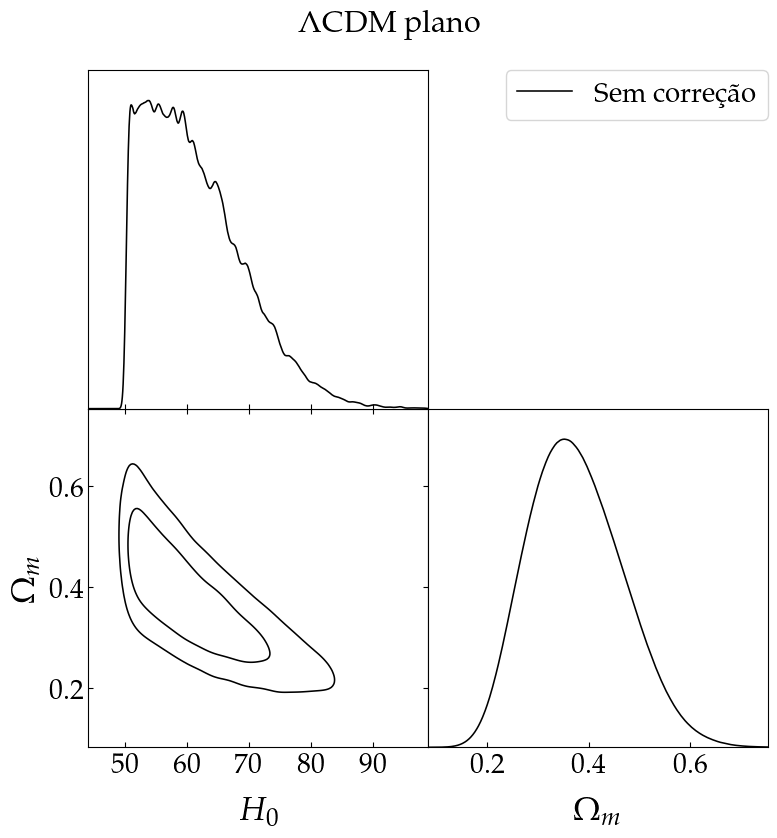

In [80]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF1], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-slib_sps-no_f.pdf')
plt.show()

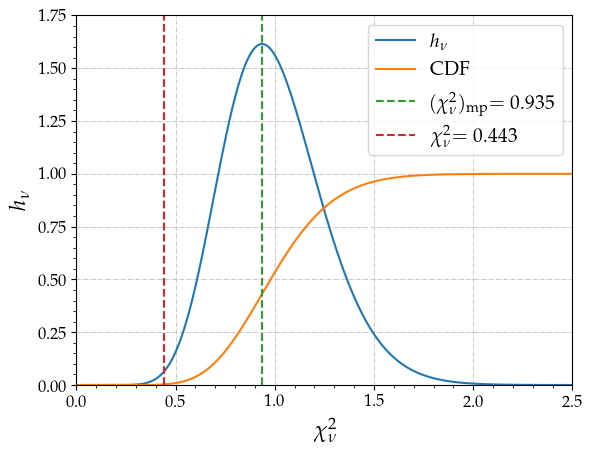

Probabilidade = 0.31001094812644%
chi2v = 0.44256530178960685
chi2v mais provável = 0.935483870967742


In [81]:
chi2_reduzido(samplesHzF, False, True, par_HzF)

## FLCDM com correção

In [82]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  58.840385936119105
wm  =  0.38085840329888004
f  =  0.6414321378868799
chi2min = 3.692575589853874
Total time: 0.011 seg


In [83]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:32<00:00, 154.22it/s]

Acceptance fraction: [0.6302 0.6196 0.6134 0.6188 0.6264 0.6254 0.6172 0.6358 0.6224 0.6318
 0.6162 0.6288 0.6292 0.6236 0.6132 0.6234 0.6376 0.632  0.6198 0.6378
 0.6232 0.6242 0.6134 0.6348 0.6142 0.6314 0.6388 0.6232 0.632  0.6312
 0.625  0.6156 0.6464 0.6386 0.628  0.6276 0.6212 0.6268 0.6098 0.6288
 0.6218 0.624  0.632  0.6262 0.6246 0.6316 0.6228 0.6332 0.6314 0.6264
 0.6286 0.6146 0.6328 0.631  0.6288 0.626  0.6272 0.6154 0.6232 0.6202
 0.616  0.6216 0.6374 0.6278 0.621  0.6388 0.6342 0.6258 0.6322 0.6238
 0.6192 0.6178 0.6166 0.6216 0.6216 0.6346 0.6248 0.635  0.6242 0.6348
 0.6342 0.6174 0.6338 0.6228 0.6274 0.6322 0.6282 0.625  0.6094 0.6234
 0.6288 0.6264 0.6276 0.6336 0.6404 0.624  0.6324 0.61   0.6254 0.6264]
Minimum acceptance: 0.6094
Maximum acceptance: 0.6464


In [84]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[38.6670301  37.64225834 39.79407721]
125.64683867533682
Convergiu! :)


In [85]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(27300, 3)


In [86]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 59.70607 +6.36163 +13.93538 -6.44445 -9.16818 (median: 58.96994, ml: 58.84039)
wm = 0.38256 +0.07354 +0.15132 -0.07296 -0.13073 (median: 0.37909, ml: 0.38086)
f = 0.68460 +0.08774 +0.21314 -0.08816 -0.15217 (median: 0.67481, ml: 0.64143)


In [87]:
gsamplesHzFf1 = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


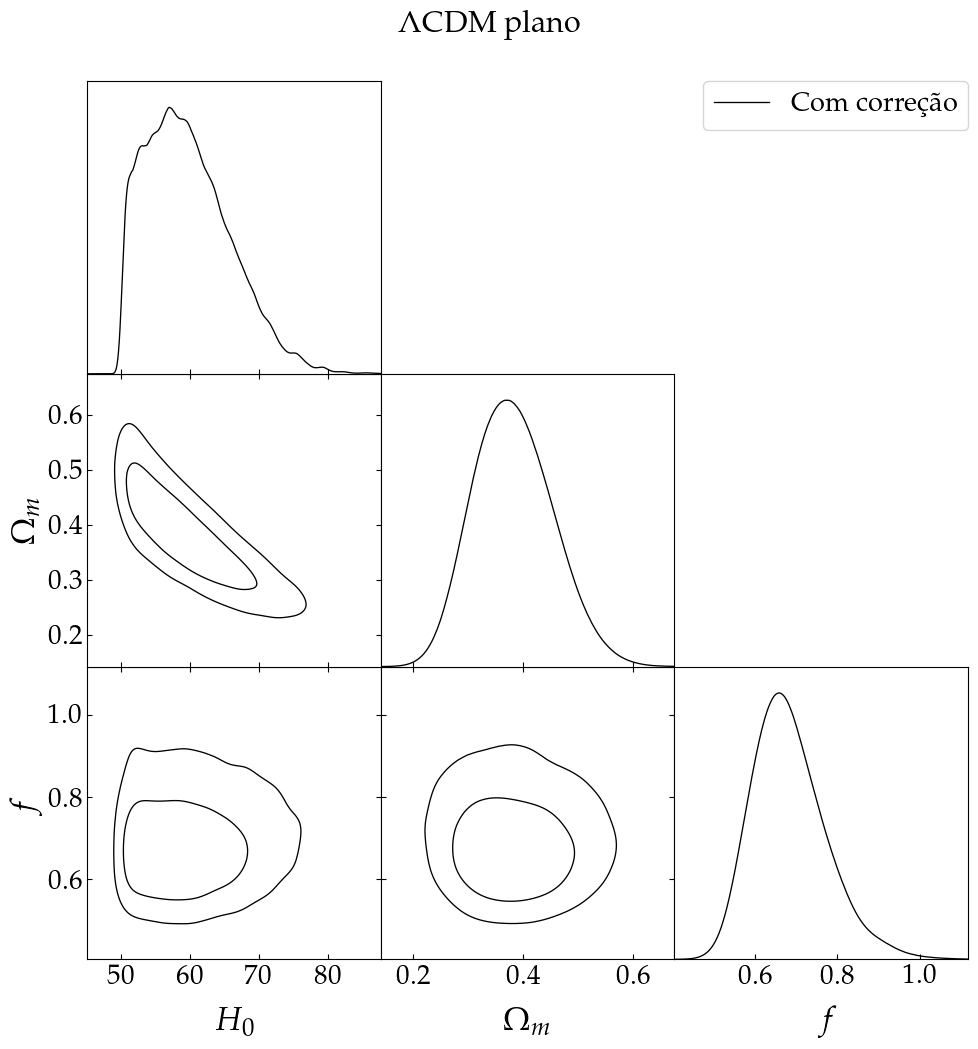

In [88]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf1], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-slib_sps-f.pdf')
plt.show()

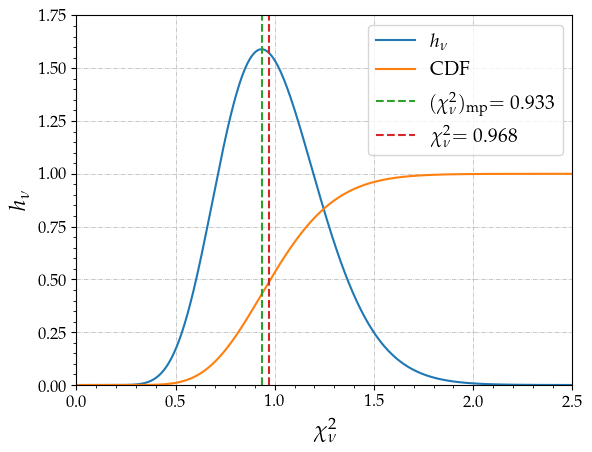

Probabilidade = 48.50471030129459%
chi2v = 0.968344911545421
chi2v mais provável = 0.9333333333333333


In [89]:
chi2_reduzido(samplesHzFf, True, True, par_HzFf)

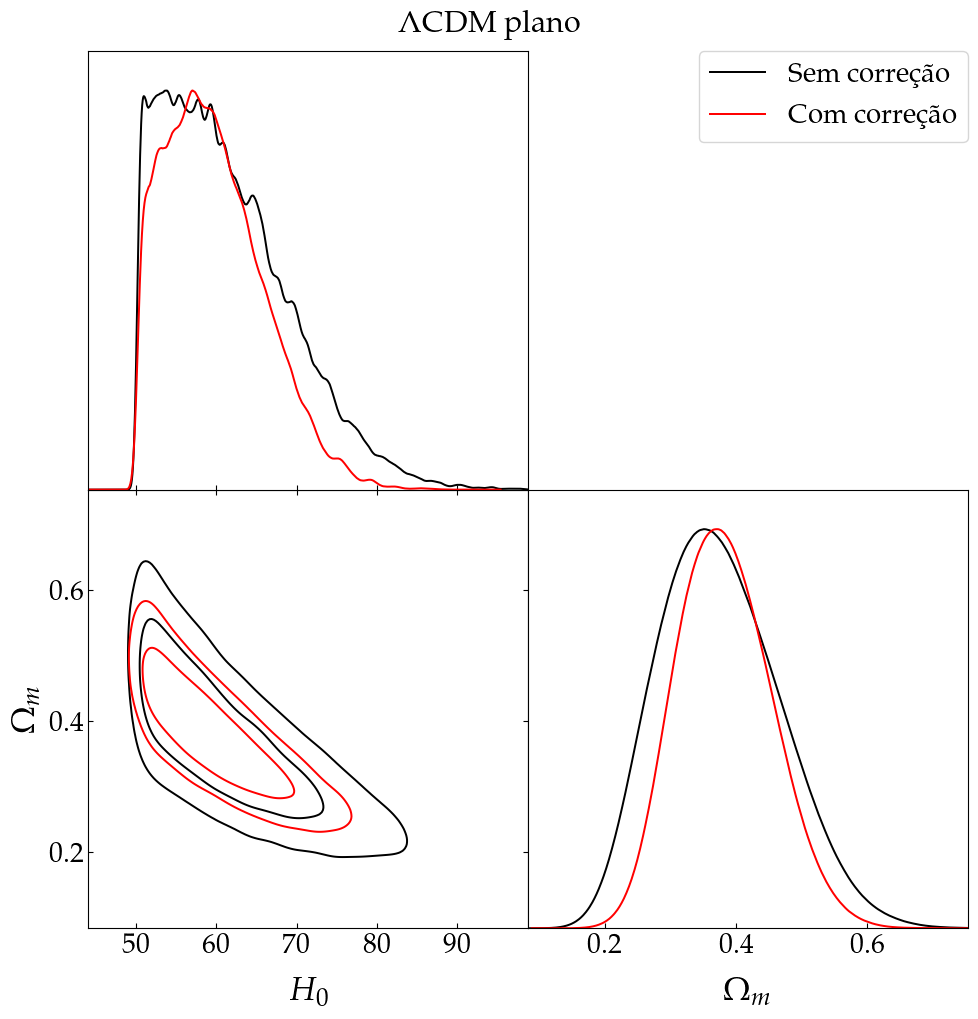

In [90]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF1, gsamplesHzFf1], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.02)
g.export('fig/FLCDM-slib_sps.pdf')
plt.show()

# Matriz de covariância: stat + imf + spsooo

In [91]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
spsooo_intp = np.interp(zhzi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

## OLCDM sem correção

In [92]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  68.23979607209058
wm  =  0.36817483747777435
wl  =  0.7664466177568645
chi2min = 14.492332505458934
Total time: 0.009 seg


In [93]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:31<00:00, 159.65it/s]

Acceptance fraction: [0.638  0.6348 0.6286 0.6258 0.626  0.6328 0.6276 0.6358 0.6292 0.6422
 0.6124 0.6252 0.6242 0.6248 0.6308 0.6416 0.6342 0.6278 0.6392 0.6338
 0.6396 0.6346 0.6252 0.6344 0.6386 0.6376 0.632  0.6402 0.632  0.6378
 0.6334 0.6372 0.6286 0.646  0.6286 0.6256 0.6354 0.6404 0.6126 0.6246
 0.6286 0.6438 0.6298 0.641  0.6338 0.6394 0.62   0.6416 0.65   0.6312
 0.6226 0.6352 0.6322 0.6354 0.6392 0.6386 0.6366 0.629  0.6248 0.6424
 0.6274 0.6268 0.6502 0.6494 0.6284 0.6334 0.6182 0.6354 0.636  0.625
 0.6422 0.6282 0.6322 0.6328 0.6416 0.6294 0.6452 0.632  0.6192 0.6342
 0.6316 0.642  0.6262 0.6322 0.635  0.631  0.6318 0.6126 0.6324 0.6264
 0.626  0.6208 0.6322 0.637  0.64   0.6238 0.6388 0.621  0.6298 0.6176]
Minimum acceptance: 0.6124
Maximum acceptance: 0.6502


In [94]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[41.44683358 39.12525243 40.43496168]
120.63647733890622
Convergiu! :)


In [95]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [96]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 66.40099 +6.35127 +12.80466 -6.42927 -12.36712 (median: 66.27697, ml: 68.23980)
wm = 0.36888 +0.20133 +0.41525 -0.20976 -0.33879 (median: 0.35957, ml: 0.36817)
wl = 0.67902 +0.40653 +0.75681 -0.41134 -0.84129 (median: 0.69550, ml: 0.76645)


In [97]:
gsamplesHzC2 = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [98]:
MCResult(gsamplesHzC2)

H0 = 66.4010 + 6.3263 + 12.6083 -6.3880 -12.0970
wm = 0.3689 + 0.1835 + 0.3340 -0.2246 -0.3689
wl = 0.6790 + 0.4320 + 0.7450 -0.3775 -0.8282


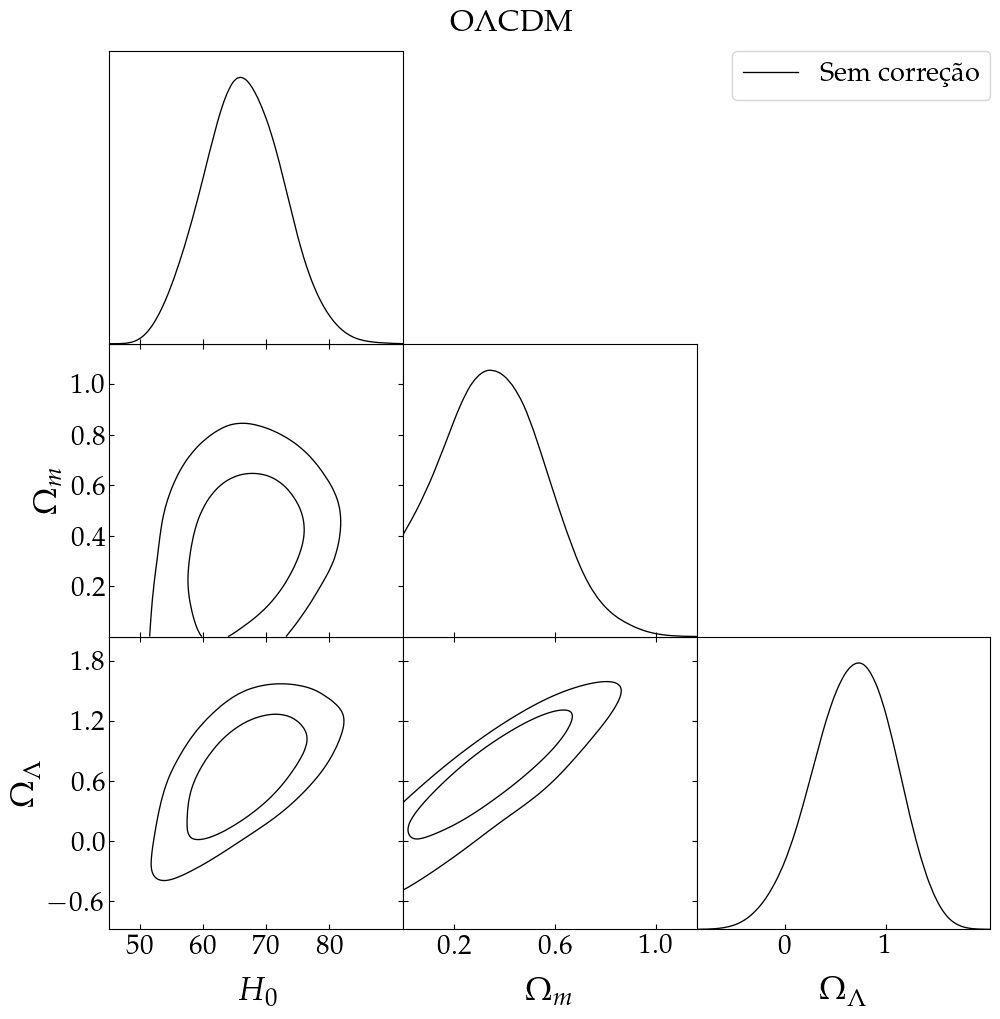

In [99]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC2], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
g.export('fig/OLCDM-spsooo-no_f.pdf')
plt.show()

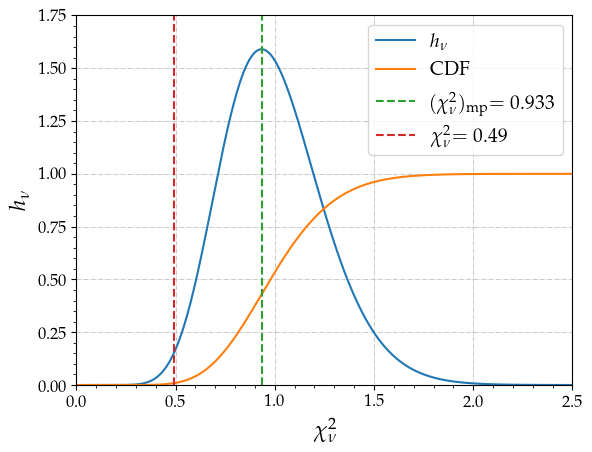

Probabilidade = 0.8719491488603187%
chi2v = 0.49032028461375277
chi2v mais provável = 0.9333333333333333


In [100]:
chi2_reduzido(samplesHzC, False, False, par_HzC)

## OLCDM com correção

In [101]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  68.23979760010327
wm  =  0.36817486786682574
wl  =  0.7664467235563078
f  =  0.6626926796390887
chi2min = 5.844701127305733
Total time: 0.010 seg


In [102]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:33<00:00, 151.14it/s]

Acceptance fraction: [0.5816 0.5914 0.5724 0.5826 0.5836 0.5796 0.581  0.5876 0.5872 0.5832
 0.576  0.585  0.5766 0.576  0.5916 0.5992 0.5956 0.5874 0.5842 0.5922
 0.5934 0.5732 0.576  0.5754 0.5902 0.5854 0.5786 0.5804 0.5838 0.5888
 0.582  0.5862 0.5958 0.6122 0.6004 0.5774 0.5874 0.5864 0.579  0.5768
 0.5756 0.5746 0.5788 0.5874 0.593  0.5964 0.5788 0.5998 0.5884 0.5832
 0.5878 0.5972 0.5886 0.5806 0.5922 0.5844 0.5824 0.5712 0.5684 0.593
 0.571  0.5792 0.5908 0.5858 0.5932 0.5882 0.5728 0.5872 0.582  0.5786
 0.5836 0.582  0.5732 0.5858 0.593  0.5826 0.587  0.586  0.5914 0.5826
 0.5866 0.5914 0.579  0.5836 0.5924 0.588  0.586  0.5814 0.584  0.5768
 0.5882 0.5752 0.582  0.6034 0.5944 0.5808 0.5864 0.5784 0.5738 0.5926]
Minimum acceptance: 0.5684
Maximum acceptance: 0.6122


In [103]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[49.79589781 45.26940129 46.19830813 47.58912905]
100.40987752456574
Convergiu! :)


In [104]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [105]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 67.01317 +4.46843 +9.20191 -4.52975 -9.53977 (median: 67.12448, ml: 68.23980)
wm = 0.35634 +0.15970 +0.32124 -0.16514 -0.30445 (median: 0.35482, ml: 0.36817)
wl = 0.69462 +0.31662 +0.59329 -0.32382 -0.66889 (median: 0.71302, ml: 0.76645)
f = 0.72498 +0.09482 +0.23494 -0.09539 -0.16371 (median: 0.71554, ml: 0.66269)


In [106]:
gsamplesHzCF2 = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


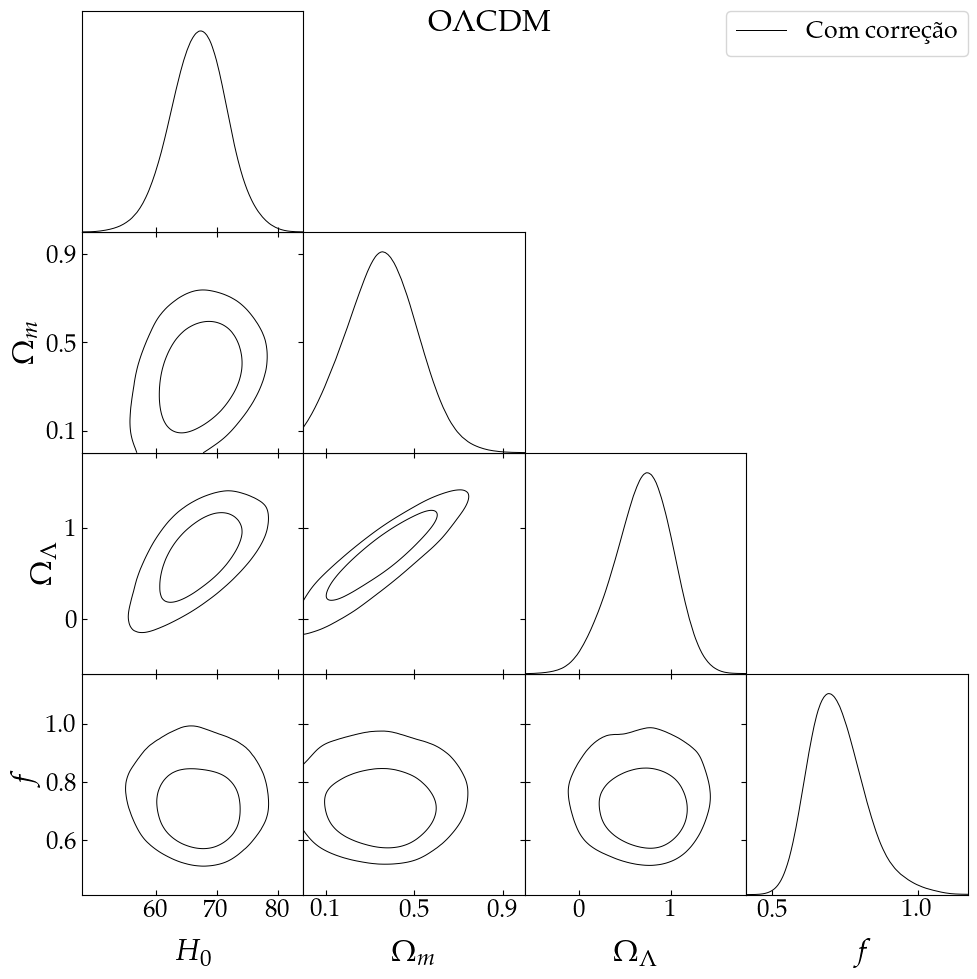

In [107]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF2], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-spsooo-f.pdf')
plt.show()

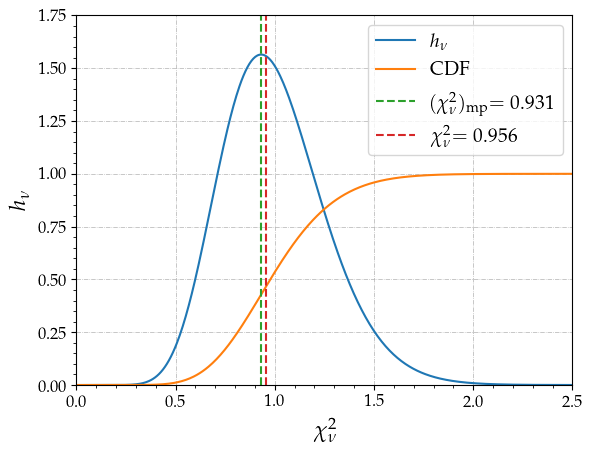

Probabilidade = 46.680797605639455%
chi2v = 0.9556865366823633
chi2v mais provável = 0.9310344827586207


In [108]:
chi2_reduzido(samplesHzCF, True, False, par_HzCF)

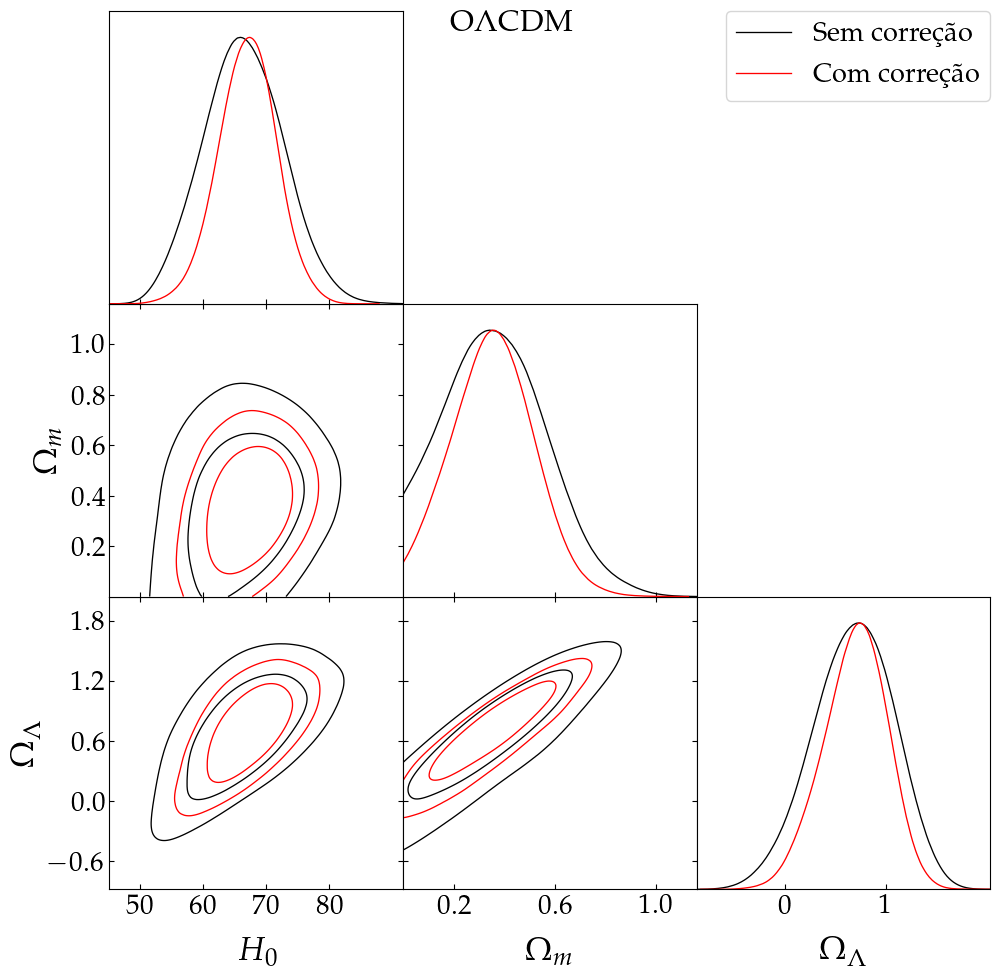

In [109]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC2, gsamplesHzCF2], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-spsooo.pdf')
plt.show()

## FLCDM sem correção

In [110]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  67.53068384148416
wm  =  0.32398578404277734
chi2min = 14.533396574606178
Total time: 0.009 seg


In [111]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:32<00:00, 151.55it/s]


Acceptance fraction: [0.7078 0.7212 0.709  0.7158 0.7118 0.7128 0.7116 0.7132 0.7232 0.725
 0.7118 0.717  0.7116 0.7094 0.7154 0.7188 0.7196 0.7074 0.7176 0.707
 0.7094 0.7264 0.7124 0.7134 0.7118 0.723  0.7146 0.7264 0.7144 0.722
 0.7148 0.7118 0.71   0.7222 0.72   0.712  0.7114 0.7204 0.6998 0.7068
 0.7086 0.7168 0.7154 0.7192 0.7084 0.7168 0.713  0.7242 0.7216 0.7124
 0.7184 0.7204 0.7168 0.7186 0.7084 0.7142 0.7156 0.7066 0.7122 0.7096
 0.7084 0.7098 0.7122 0.7168 0.7232 0.7122 0.7118 0.7128 0.7136 0.7096
 0.7208 0.714  0.715  0.7038 0.7148 0.7202 0.7274 0.7026 0.716  0.711
 0.6972 0.7122 0.712  0.7164 0.7148 0.7216 0.7106 0.7082 0.7082 0.7106
 0.709  0.7108 0.7204 0.7216 0.7144 0.7024 0.7222 0.6988 0.7312 0.704 ]
Minimum acceptance: 0.6972
Maximum acceptance: 0.7312


In [112]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[31.71149456 32.07019295]
155.90801112559197
Convergiu! :)


In [113]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(32900, 2)


In [114]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 66.69724 +5.44485 +10.88233 -5.39085 -10.78039 (median: 66.68702, ml: 69.19300)
wm = 0.34230 +0.07040 +0.17031 -0.07020 -0.12088 (median: 0.33390, ml: 0.24809)


In [115]:
gsamplesHzF2 = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


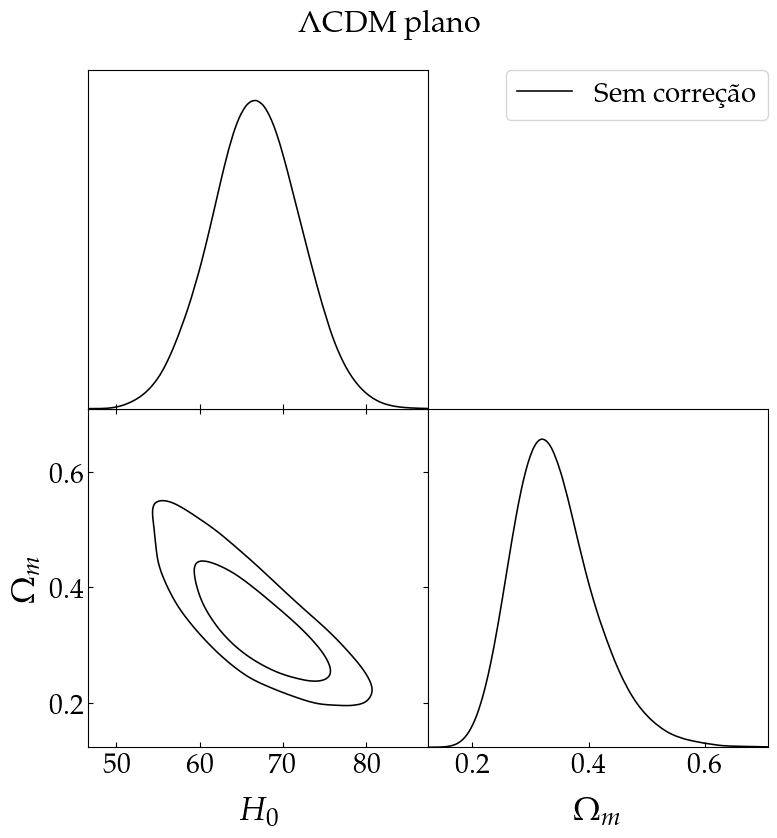

In [116]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF2], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-spsooo-no_f.pdf')
plt.show()

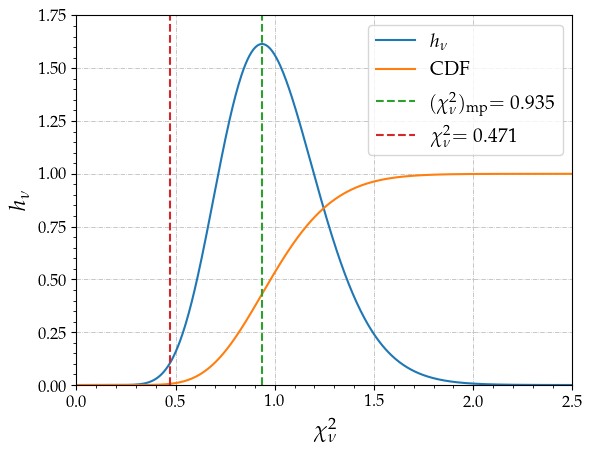

Probabilidade = 0.5508548830665031%
chi2v = 0.47146768809038925
chi2v mais provável = 0.935483870967742


In [117]:
chi2_reduzido(samplesHzF, False, True, par_HzF)

## FLCDM com correção

In [118]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  67.53067072166489
wm  =  0.32398590831550955
f  =  0.6636308715882958
chi2min = 5.938074505277914
Total time: 0.011 seg


In [119]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:34<00:00, 146.53it/s]

Acceptance fraction: [0.6454 0.6484 0.631  0.6474 0.6416 0.6356 0.6406 0.6364 0.6394 0.6468
 0.6382 0.6278 0.6286 0.6412 0.6394 0.6382 0.6476 0.6364 0.644  0.6378
 0.6466 0.648  0.6368 0.6416 0.6466 0.6486 0.6436 0.6456 0.6352 0.6454
 0.6438 0.6424 0.644  0.657  0.6514 0.6406 0.6494 0.6382 0.6364 0.6378
 0.6316 0.636  0.6524 0.6492 0.645  0.647  0.6368 0.6606 0.6544 0.6352
 0.6338 0.634  0.6506 0.6402 0.6372 0.6456 0.6488 0.6366 0.634  0.6456
 0.6222 0.6358 0.639  0.6468 0.6402 0.6494 0.6318 0.6344 0.645  0.643
 0.6434 0.6418 0.6472 0.6436 0.6496 0.643  0.658  0.6408 0.637  0.6398
 0.6384 0.6506 0.6406 0.6464 0.6414 0.6366 0.6372 0.6436 0.6392 0.6444
 0.6402 0.636  0.6406 0.6468 0.657  0.641  0.6428 0.6318 0.6484 0.6394]
Minimum acceptance: 0.6222
Maximum acceptance: 0.6606


In [120]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[37.58017508 36.39956199 37.57735751]
133.0488745594284
Convergiu! :)


In [121]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(27300, 3)


In [122]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 67.05150 +3.83925 +7.76156 -3.84767 -8.13873 (median: 67.11702, ml: 67.53067)
wm = 0.33400 +0.04863 +0.11733 -0.04875 -0.08834 (median: 0.32926, ml: 0.32399)
f = 0.71347 +0.09158 +0.21951 -0.09167 -0.16028 (median: 0.70341, ml: 0.66363)


In [123]:
gsamplesHzFf2 = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


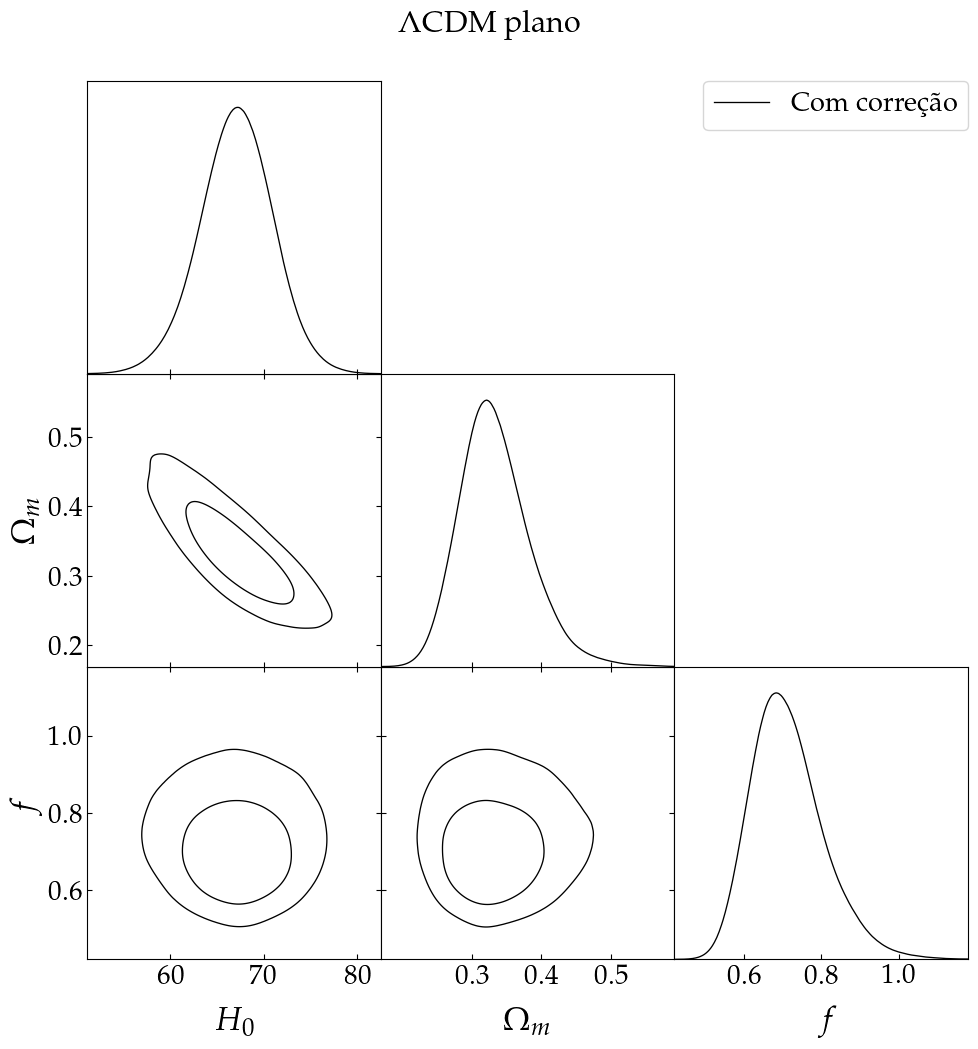

In [124]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf2], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
g.export('fig/FLCDM-spsooo-f.pdf')
plt.show()

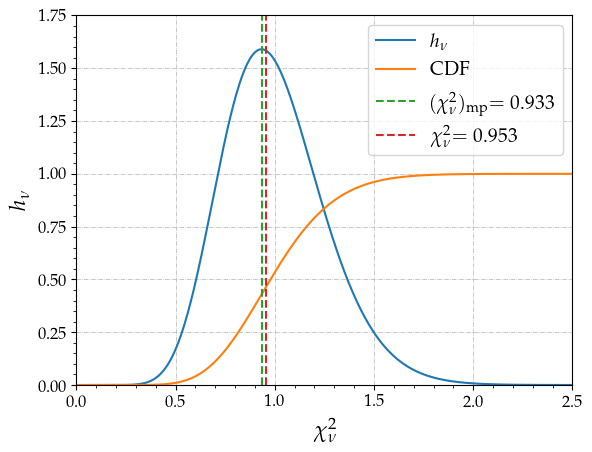

Probabilidade = 46.126531841803875%
chi2v = 0.9532948193211221
chi2v mais provável = 0.9333333333333333


In [125]:
chi2_reduzido(samplesHzFf, True, True, par_HzFf)

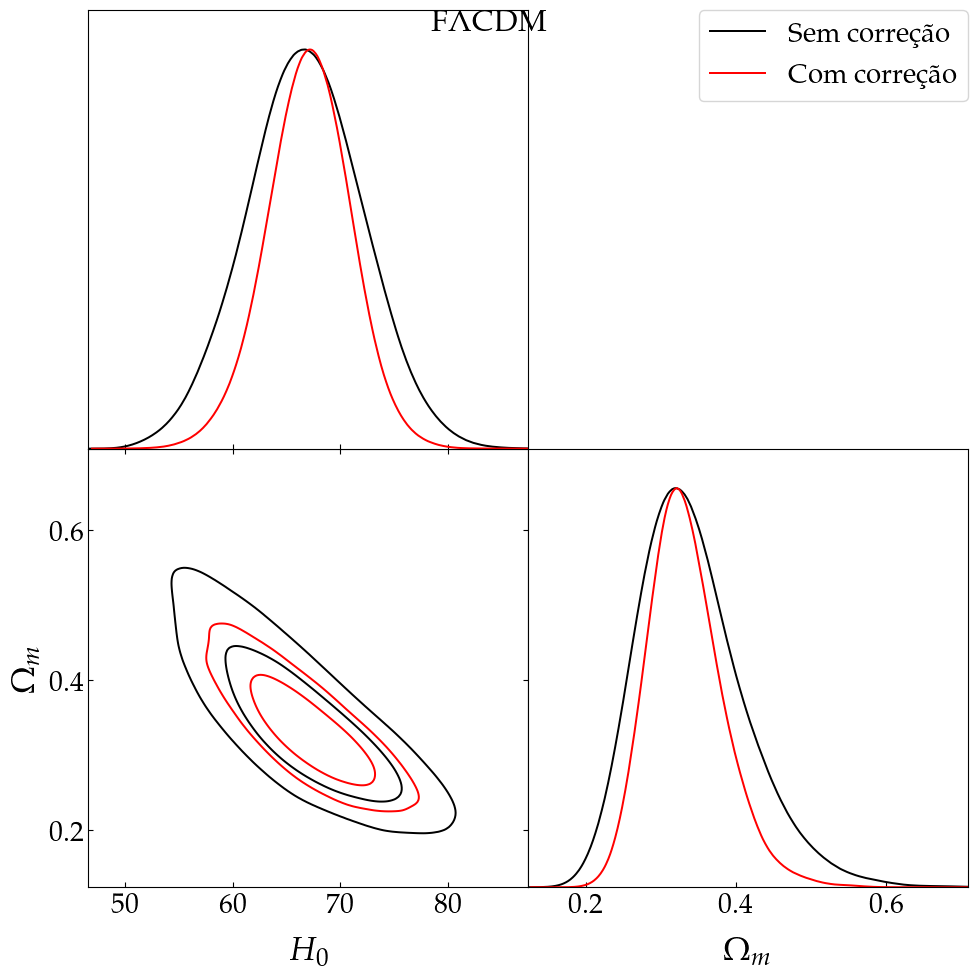

In [126]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF2, gsamplesHzFf2], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22)
g.export('fig/FLCDM-spsooo.pdf')
plt.show()

# Resultados
## OLCDM sem correção

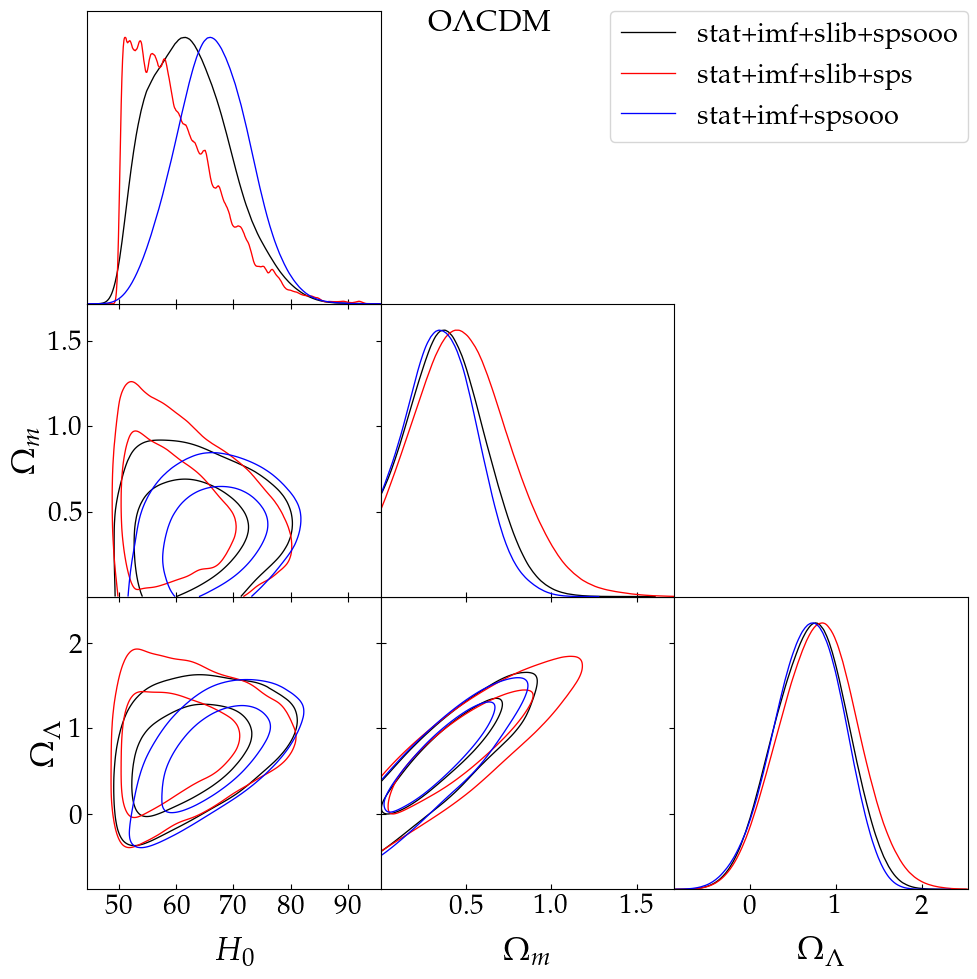

In [128]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC_cons, gsamplesHzC1, gsamplesHzC2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
g.export('fig/OLCDM-matrizes-no_f.pdf')
plt.show()

## OLCDM com correção

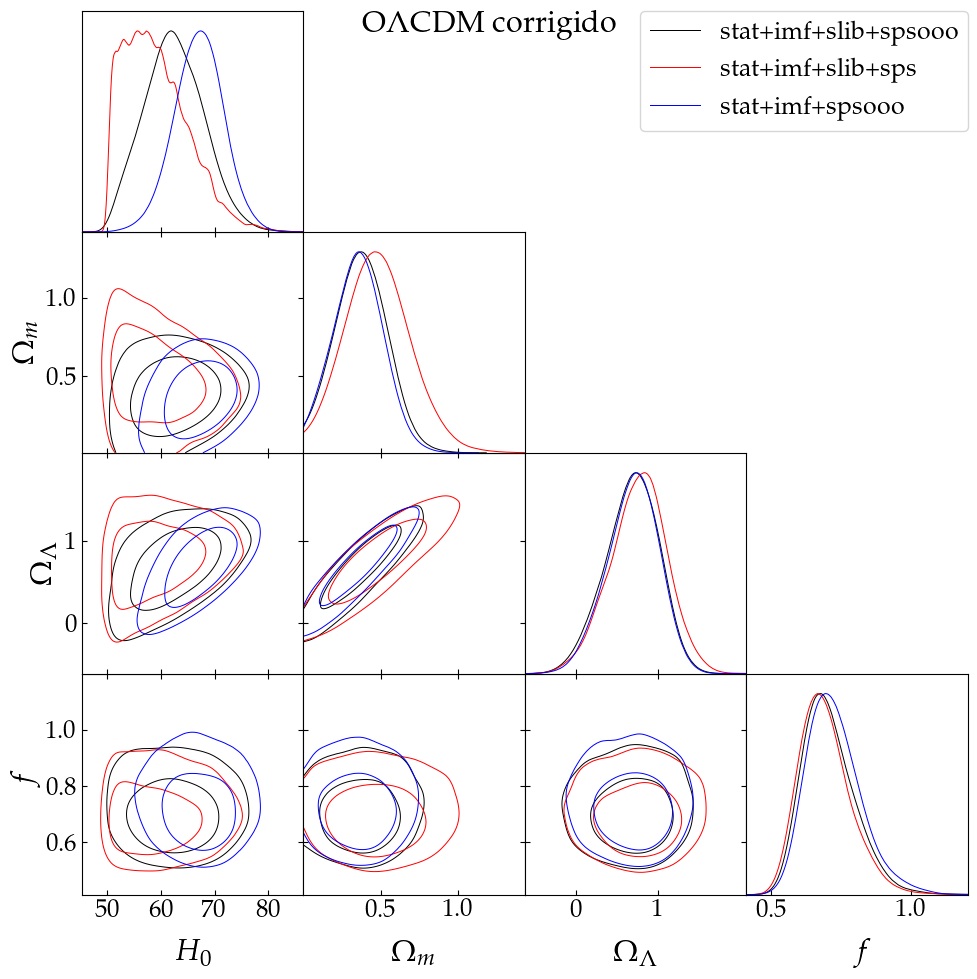

In [129]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF_cons, gsamplesHzCF1, gsamplesHzCF2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM corrigido", fontsize=22)
g.export('fig/OLCDM-matrizes-f.pdf')
plt.show()

## FLCDM sem correção

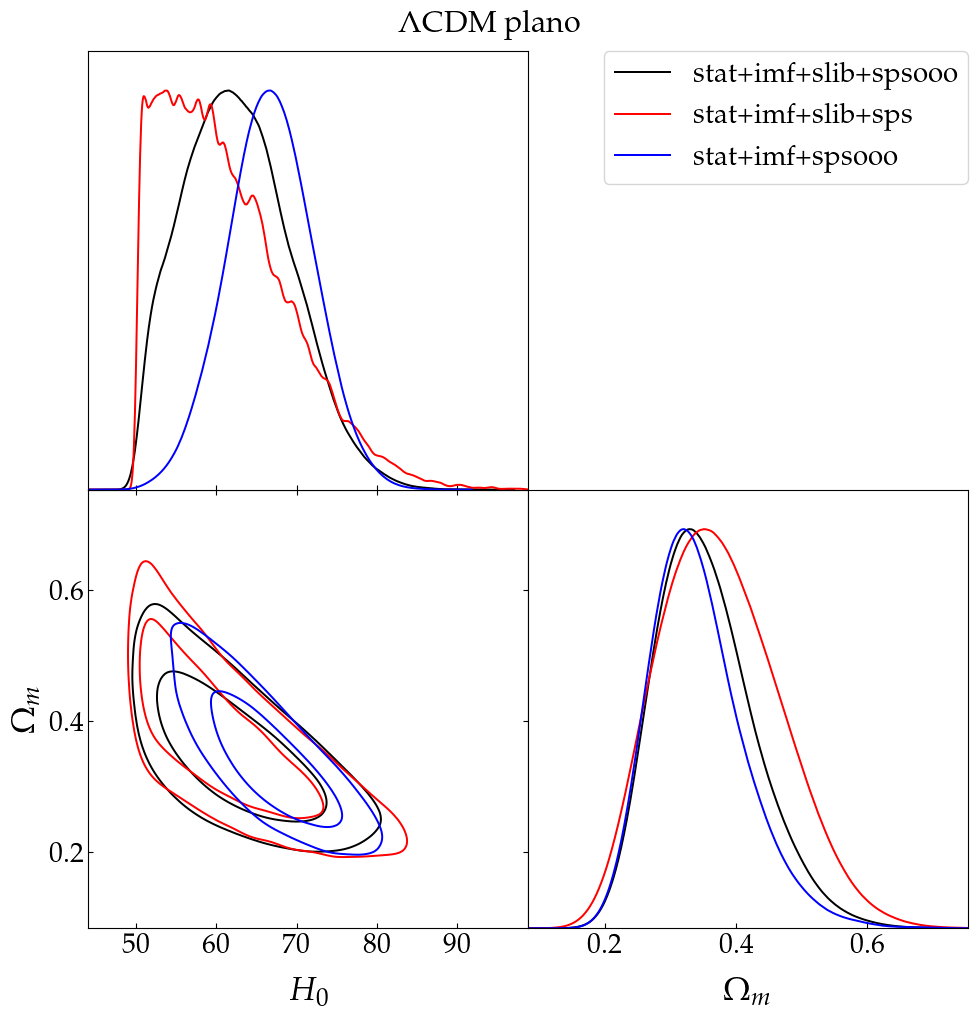

In [131]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF_cons, gsamplesHzF1, gsamplesHzF2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.02)
g.export('fig/FLCDM-matrizes-no_f.pdf')
plt.show()

## FLCDM com correção

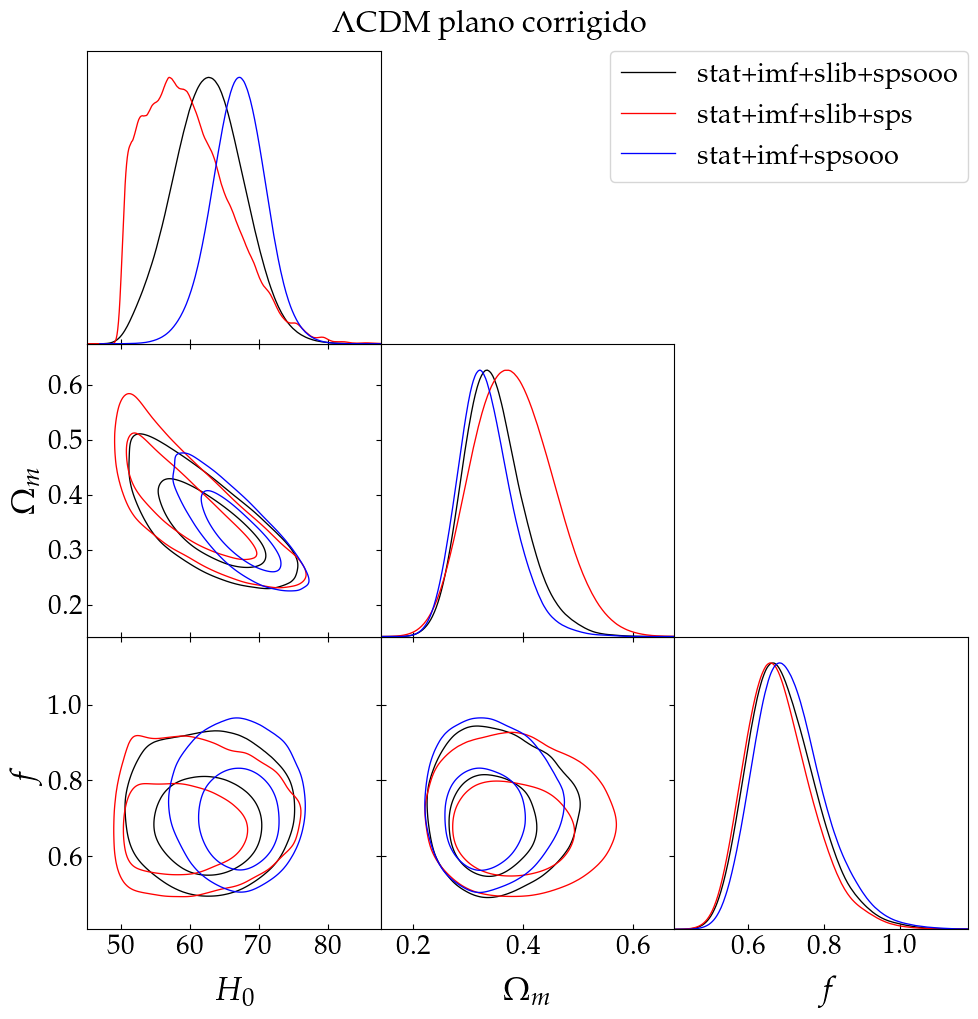

In [133]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf_cons, gsamplesHzFf1, gsamplesHzFf2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"$\Lambda$CDM plano corrigido", fontsize=22, y=1.02)
g.export('fig/FLCDM-matrizes-f.pdf')
plt.show()